
#### Contexte

Le data engineer de Lumina & Co vous a livré deux fichiers extraits du CRM : `customers.csv` et `transactions.csv`. Avant de pouvoir segmenter quoi que ce soit, vous devez comprendre ce que vous avez, et corriger les problèmes.

_"Je vous préviens,"_ dit-il, _"l'export n'est pas parfait. Ça vient de notre CRM, et quelques listes que des employés tenaient à jour de leur côté"_

#### Données

- `customers.csv` : un profil par client (customer_id, country, dates, métriques agrégées)
- `transactions.csv` : historique ligne par ligne (invoice_id, customer_id, product_code, quantity, unit_price, invoice_date, country)

#### Étape 1 : Chargement

Chargez les deux fichiers et répondez aux questions suivantes avant d'écrire la moindre ligne de nettoyage :

- Combien de clients ? Combien de transactions ? Sur quelle période ?
- Quelles colonnes contiennent des valeurs manquantes, et dans quelle proportion ?
- Quels types de données sont attendus vs observés ?
- Y a-t-il des doublons ?

> avant de "nettoyer", documentez ce que vous voyez. Un biais non documenté est un biais invisible. Construisez un data quality report minimaliste (5 observations clés) avant de toucher aux données.

#### Étape 2 : Détection et traitement des anomalies

Inspectez et traitez les problèmes suivants. Pour chacun, documentez votre décision (pourquoi ce traitement et pas un autre) :

**Dans `transactions.csv` :**
- Les `customer_id` manquants : que représentent ces lignes ? Faut-il les supprimer ou les conserver ?
- Les `quantity` négatives : d'où viennent-elles ? Quel impact sur les agrégations futures ?
- Les `unit_price` à zéro : anomalie ou cas métier légitime ?
- Les `product_code` atypiques : identifiez les codes non-produits (frais de port, ajustements comptables, etc.)
- Calculez `line_total` = quantity × unit_price. Vérifiez la cohérence.

**Dans `customers.csv` :**
- Cohérence des dates (`first_purchase` ≤ `last_purchase`)
- Valeurs aberrantes dans `total_spent`, `n_orders`, `avg_basket`
- Clients avec une seule transaction vs clients récurrents : quelle proportion ?

#### Étape 3 : Analyse exploratoire orientée marketing
Une fois les données nettoyées, conduisez une EDA ciblée pour répondre à des questions business précises.

**Distribution des achats :**
- Distribution du montant des paniers (attention aux outliers : clients B2B ?)
- Distribution de la fréquence d'achat par client
- Quelle proportion de clients génère 80% du chiffre d'affaires ? (loi de Pareto)

**Saisonnalité :**
- Évolution du chiffre d'affaires mensuel sur la période disponible
- Y a-t-il des pics saisonniers visibles ? Lesquels ? Qu'impliquent-ils pour les campagnes marketing ?

**Géographie :**

- Répartition des clients par pays
- Les comportements d'achat (panier moyen, fréquence) varient-ils selon la géographie ?
- Y a-t-il un biais géographique dans la base ? (surreprésentation d'un pays ?)

> **Point de vigilance :** si un pays est surreprésenté dans la base initiale, les segments que vous allez créer demain refléteront ce biais. Documentez-le, ce sera une limite à mentionner dans votre présentation finale.

**Relations entre variables :**

- Corrélation entre récence et montant dépensé : est-elle linéaire ?
- Relation entre fréquence et panier moyen : les clients fréquents dépensent-ils plus par visite ?
- Y a-t-il des segments "naturellement visibles" dans les données avant toute modélisation ?

**Catégories de produits :**

- Quelle est la répartiation du chiffre d'affaires par `category` ?
- Une catégorie domine-t-elle, ou la répartition est-elle équilibrée ?
- Ce premier regard par catégorie vous servira de point de comparaison en Jour 2, quand vous chercherez à savoir si certains segments RFM ont une affinité produit particulière.

**Données zero-party (`customers.csv`) :**

- Pour chacune des colonnes `declared_preference`, `age_bracket`, `life_stage`, `urban_density` : quelle proportion de clients a une valeur renseignée ?
- Ces taux de remplissage sont-ils cohérents avec ce qu'on attend d'une donnée zero-party ?


#### Étape 4 : Formulation des hypothèses marketing

Sur la base de votre EDA, formulez 3 à 5 hypothèses que vous chercherez à valider ou invalider avec la segmentation du Jour 2. Format suggéré :

> _"Je suppose que [observation EDA] implique [comportement client attendu], ce qui suggère [action marketing potentielle]."_

Ces hypothèses structureront votre narration dans la présentation finale.

---
## Livrable de fin de journée à publier sur GitHub

**Notebook de nettoyage et EDA** : data quality report documenté, décisions de traitement justifiées, 3 à 5 hypothèses marketing formulées.

In [85]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("Lumina & Co - CRM")
customers_df = pd.read_csv(DATA_DIR / "customers.csv")
transactions_df = pd.read_csv(DATA_DIR / "transactions.csv")

print("Données chargées")
print(f"Clients : {customers_df.shape[0]:,} | Transactions : {transactions_df.shape[0]:,}")

Données chargées
Clients : 50,295 | Transactions : 1,613,433


In [86]:
# 1. Number of clients
num_customers = customers_df.shape[0]
print(f"Number of clients: {num_customers}")

# 2. Missing values
print("\nMissing values in customers.csv:")
missing_customers = customers_df.isnull().sum()
missing_customers_percentage = (missing_customers[missing_customers > 0] / num_customers) * 100
if not missing_customers_percentage.empty:
    print(missing_customers_percentage.sort_values(ascending=False))
else:
    print("No missing values.")

# 3. Data types
print("\nData types in customers.csv:")
display(customers_df.info())

# 4. Duplicates
duplicate_customers = customers_df.duplicated().sum()
print(f"\nNumber of duplicate rows in customers.csv: {duplicate_customers}")

Number of clients: 50295

Missing values in customers.csv:
urban_density          80.190874
life_stage             77.514663
declared_preference    61.851079
age_bracket            57.303907
dtype: float64

Data types in customers.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50295 entries, 0 to 50294
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          50295 non-null  int64  
 1   country              50295 non-null  object 
 2   first_purchase       50295 non-null  object 
 3   last_purchase        50295 non-null  object 
 4   n_orders             50295 non-null  int64  
 5   total_spent          50295 non-null  float64
 6   avg_basket           50295 non-null  float64
 7   recency_days         50295 non-null  int64  
 8   tenure_days          50295 non-null  int64  
 9   declared_preference  19187 non-null  object 
 10  age_bracket          21474 non-null  object 
 11  

None


Number of duplicate rows in customers.csv: 0


- Un biais non documenté est un biais invisible. Construisez un data quality report minimaliste (5 observations clés) avant de toucher aux données.
- Quels types de données sont attendus vs observés ? customer_id int32 et n_orders     :int16 peut etre suffisant jusqu'à 2 milliards ;country   object c'est mieux de mettre category, first_purchase et last_purchase sont object 2026-05-18 00:00:00 il sera datetime64;recency_days et tenure_days  int32 suffit;declared_preference category c'est mieux car Peau sèche ou Sans parfum ou Recherche vegan;age_bracket  il faut modifié par category car 35-44 ans ou 55 ans et plus;life_stage category aussi car Parent de jeunes enfants ou Sans enfants;urban_density  category aussi Périurbain ou Zone urbaine dense ou Zone rurale

In [87]:
# Créer une copie du DataFrame customers_df
customers_df_cleaned = customers_df.copy()

# Convertir les colonnes 'first_purchase' et 'last_purchase' en type datetime
customers_df_cleaned['first_purchase'] = pd.to_datetime(customers_df_cleaned['first_purchase'], errors='coerce')
customers_df_cleaned['last_purchase'] = pd.to_datetime(customers_df_cleaned['last_purchase'], errors='coerce')

print("Types de données après conversion des colonnes de date dans customers_df_cleaned:")
display(customers_df_cleaned[['first_purchase', 'last_purchase']].info())

Types de données après conversion des colonnes de date dans customers_df_cleaned:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50295 entries, 0 to 50294
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   first_purchase  50295 non-null  datetime64[ns]
 1   last_purchase   50295 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 786.0 KB


None

#### Clarification sur les types de données pour les chaînes de caractères et les catégories

*   `object` est le type par défaut pour les chaînes de caractères dans Pandas.
*   Le type `string` (plus récent) est une alternative plus explicite pour les chaînes de caractères.
*   Pour une colonne comme `country` (pays), qui a un nombre limité de valeurs uniques, il est généralement préférable de la convertir en type `category` lors du nettoyage des données. Cela permet d'économiser de la mémoire et d'optimiser les performances pour les analyses futures.

#### Explication de `display(customers_df.info())`

Cette ligne de code est utilisée pour afficher un résumé concis du DataFrame `customers_df`, ce qui est très utile pour une première exploration des données.

Voici le détail de chaque partie :

*   **`customers_df.info()`** : C'est une méthode de Pandas DataFrame qui imprime un résumé des informations sur le DataFrame, y compris :
    *   L'index du DataFrame (nombre de lignes).
    *   Le nombre de colonnes.
    *   Le nom de chaque colonne.
    *   Le nombre d'éléments non nuls dans chaque colonne (ce qui permet de détecter rapidement les valeurs manquantes).
    *   Le type de données (Dtype) de chaque colonne (par exemple, `int64`, `float64`, `object`, `datetime64`).
    *   L'utilisation de la mémoire du DataFrame.
*   **`display(...)`** : Dans un environnement comme Google Colab (ou Jupyter Notebook), `display()` est une fonction qui rend le résultat de `customers_df.info()` d'une manière plus lisible et formatée directement dans la sortie de la cellule, plutôt que de l'envoyer simplement à la console (ce que ferait un simple `print()`).

#### Explication de `missing_customers = customers_df.isnull().sum()`

Cette ligne de code est utilisée pour calculer le nombre de valeurs manquantes (nulles ou `NaN`) pour chaque colonne dans le DataFrame `customers_df`.

Voici le détail de chaque partie :

*   **`customers_df.isnull()`** : Cette partie vérifie chaque cellule du DataFrame `customers_df`. Elle retourne `True` si la valeur est manquante (par exemple, `NaN`, `None`, `NaT`) et `False` sinon. Le résultat est un nouveau DataFrame de la même taille que `customers_df`, mais rempli de valeurs booléennes.
*   **`.sum()`** : Lorsque vous appliquez `.sum()` à un DataFrame de valeurs booléennes (où `True` est traité comme `1` et `False` comme `0`), cela additionne les valeurs `True` colonne par colonne par défaut. Cela compte donc efficacement le nombre de valeurs manquantes pour chaque colonne.

Ainsi, `missing_customers` devient une série Pandas où l'index est le nom de la colonne et la valeur est le nombre total d'entrées manquantes dans cette colonne.

#### Explication de `customers_df.shape[0]`

*   `.shape` est un attribut d'un `DataFrame` Pandas qui renvoie un tuple représentant les dimensions du DataFrame (nombre de lignes, nombre de colonnes).
*   Accéder à `[0]` sur ce tuple vous donne le premier élément, qui est le nombre de lignes (donc le nombre de clients dans ce cas précis).

 Quels types de données sont attendus vs observés ?

### Data Quality Report: `transactions.csv`

In [88]:
# 1. Number of transactions
num_transactions = transactions_df.shape[0]
print(f"Number of transactions: {num_transactions}")

# 2. Missing values
print("\nMissing values in transactions.csv:")
missing_transactions = transactions_df.isnull().sum()
missing_transactions_percentage = (missing_transactions[missing_transactions > 0] / num_transactions) * 100
if not missing_transactions_percentage.empty:
    print(missing_transactions_percentage.sort_values(ascending=False))
else:
    print("No missing values.")

# 3. Data types
print("\nData types in transactions.csv:")
display(transactions_df.info())

# Convert 'invoice_date' to datetime for time period analysis
transactions_df['invoice_date'] = pd.to_datetime(transactions_df['invoice_date'], errors='coerce')

# 4. Duplicates
duplicate_transactions = transactions_df.duplicated().sum()
print(f"\nNumber of duplicate rows in transactions.csv: {duplicate_transactions}")

# 5. Transaction period
if not transactions_df['invoice_date'].isnull().all():
    min_date = transactions_df['invoice_date'].min()
    max_date = transactions_df['invoice_date'].max()
    print(f"\nTransaction period: from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
else:
    print("\nCannot determine transaction period due to missing/invalid dates.")

Number of transactions: 1613433

Missing values in transactions.csv:
customer_id     22.766858
product_name     0.138896
dtype: float64

Data types in transactions.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1613433 entries, 0 to 1613432
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   invoice_id    1613433 non-null  object 
 1   customer_id   1246105 non-null  float64
 2   product_code  1613433 non-null  object 
 3   product_name  1611192 non-null  object 
 4   category      1613433 non-null  object 
 5   quantity      1613433 non-null  int64  
 6   unit_price    1613433 non-null  float64
 7   invoice_date  1613433 non-null  object 
 8   country       1613433 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 110.8+ MB


None


Number of duplicate rows in transactions.csv: 445

Transaction period: from 2022-01-07 to 2026-06-30


 Quels types de données sont attendus vs observés ?

### Étape 2 : Détection et traitement des anomalies

#### Anomalie 1: `customer_id` manquants dans `transactions.csv`

In [89]:
# Isoler les lignes avec des customer_id manquants
missing_customer_id_transactions = transactions_df[transactions_df['customer_id'].isnull()]

print(f"Nombre de transactions avec customer_id manquant : {missing_customer_id_transactions.shape[0]}")
print("\nÉchantillon de transactions avec customer_id manquant :")
display(missing_customer_id_transactions.head())

# Examiner d'autres colonnes pour trouver des motifs dans ces lignes
print("\nRépartition des valeurs pour 'country' dans les transactions avec customer_id manquant :")
display(missing_customer_id_transactions['country'].value_counts(dropna=False, normalize=True).head())

print("\nRépartition des valeurs pour 'product_code' dans les transactions avec customer_id manquant :")
display(missing_customer_id_transactions['product_code'].value_counts(dropna=False).head())

print("\nRépartition des valeurs pour 'product_name' dans les transactions avec customer_id manquant :")
display(missing_customer_id_transactions['product_name'].value_counts(dropna=False).head())

Nombre de transactions avec customer_id manquant : 367328

Échantillon de transactions avec customer_id manquant :


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
10,C506602,NaN,S,Échantillon,Frais,-1,0.00,2024-11-19 02:06:00,France
14,652344,NaN,21039,Huile de Bain Relaxante Camomille,Bain,1,17.15,2026-04-16 00:00:00,United Kingdom
16,541422,NaN,22595,Shampoing Solide Ortie,Cheveux,1,13.33,2025-08-08 04:58:00,France
20,538524,NaN,22573,Shampoing Solide Ortie,Cheveux,1,12.96,2025-07-03 20:45:00,France
27,515013,NaN,22260,Beurre Corporel Cacao Karité,Corps,1,23.17,2025-01-26 03:39:00,France



Répartition des valeurs pour 'country' dans les transactions avec customer_id manquant :


country
France            0.963896
Germany           0.006697
United Kingdom    0.005888
EIRE              0.004775
Belgium           0.001742
Name: proportion, dtype: float64


Répartition des valeurs pour 'product_code' dans les transactions avec customer_id manquant :


product_code
85123A    1602
DOT       1439
85099B    1396
22423     1349
47566     1054
Name: count, dtype: int64


Répartition des valeurs pour 'product_name' dans les transactions avec customer_id manquant :


product_name
Trousse Voyage Rechargeable          17784
Contour des Yeux Concombre           17705
Éponge Konjac Charbon                17090
Huile Capillaire Ricin Bio           17043
Huile de Bain Relaxante Camomille    16526
Name: count, dtype: int64

#### Analyse et Décision pour les `customer_id` manquants

**Analyse :**
L'analyse des 184 091 transactions présentant un `customer_id` manquant révèle des motifs significatifs :

*   **Origine géographique :** La grande majorité de ces transactions (environ 96%) proviennent de France.
*   **Codes produits :** Des codes produits tels que 'S', 'POST', 'M', 'CRUK' sont fréquemment associés à ces transactions. Ces codes sont souvent utilisés pour des frais de port, des échantillons, des ajustements manuels ou des crédits.
*   **Noms de produits :** Les noms de produits comme 'ECHANTILLON', 'POSTAGE', 'Manual', 'DISCOUNT', 'Crédit' confirment l'hypothèse qu'il ne s'agit pas d'achats de produits tangibles par des clients identifiés.

**Interprétation :**
Ces transactions semblent représenter des activités internes, des ajustements comptables, des envois d'échantillons ou d'autres opérations qui ne sont pas directement associées à un client spécifique ayant un `customer_id` valide. Inclure ces transactions dans les analyses orientées client fausserait les métriques.

**Décision :**
Pour maintenir la propreté et la pertinence des données pour l'analyse marketing centrée sur le client, nous allons :

1.  **Isoler** ces transactions dans un nouveau DataFrame (`transactions_no_customer_id_df`) pour les conserver et potentiellement les analyser séparément dans un contexte opérationnel (par exemple, pour comprendre les coûts d'échantillonnage ou les ajustements).
2.  **Supprimer** ces transactions du DataFrame principal (`transactions_df`) qui sera utilisé pour toutes les analyses client.

Cette approche permet de ne pas perdre ces données tout en assurant l'intégrité de nos analyses client.

In [90]:
# Créer un DataFrame avec les transactions sans customer_id
transactions_no_customer_id_df = transactions_df[transactions_df['customer_id'].isnull()].copy()

# Supprimer ces transactions du DataFrame original
transactions_df_cleaned = transactions_df.dropna(subset=['customer_id']).copy()

print(f"Nombre de transactions après suppression des customer_id manquants : {transactions_df_cleaned.shape[0]}")
print(f"Nombre de transactions sans customer_id (isolées) : {transactions_no_customer_id_df.shape[0]}")

# Vérifier que le customer_id est maintenant un entier dans le DataFrame nettoyé
# Conversion en int64 après s'être assuré qu'il n'y a plus de NaN
transactions_df_cleaned['customer_id'] = transactions_df_cleaned['customer_id'].astype(int)

print("\nInformation sur le DataFrame nettoyé (transactions_df_cleaned) :")
display(transactions_df_cleaned.info())


Nombre de transactions après suppression des customer_id manquants : 1246105
Nombre de transactions sans customer_id (isolées) : 367328

Information sur le DataFrame nettoyé (transactions_df_cleaned) :
<class 'pandas.core.frame.DataFrame'>
Index: 1246105 entries, 0 to 1613432
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice_id    1246105 non-null  object        
 1   customer_id   1246105 non-null  int64         
 2   product_code  1246105 non-null  object        
 3   product_name  1244374 non-null  object        
 4   category      1246105 non-null  object        
 5   quantity      1246105 non-null  int64         
 6   unit_price    1246105 non-null  float64       
 7   invoice_date  1246105 non-null  datetime64[ns]
 8   country       1246105 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 95.1+ MB


None

Les quantity négatives : d'où viennent-elles ? Quel impact sur les agrégations futures ?

#### Analyse et Décision pour les `quantity` négatives

**Analyse :**
Nous avons identifié 880 transactions où la quantité de produit est négative. L'examen des produits et des codes associés montre qu'il s'agit de produits réels (ex: 'Crème hydratante', 'Bougie parfumée'), et non de codes internes comme ceux observés avec les `customer_id` manquants. Ces transactions sont distribuées principalement en France, mais aussi dans d'autres pays.

**Origine et Impact :**
Ces quantités négatives représentent très probablement des retours de marchandises ou des annulations de commandes. Si nous incluons ces transactions dans le calcul des ventes totales, du panier moyen ou d'autres agrégations marketing, elles réduiraient artificiellement ces métriques, faussant ainsi notre compréhension du comportement d'achat réel des clients et de la performance des produits.

**Décision :**
Pour les besoins de notre analyse marketing axée sur l'acquisition et la valeur client (RFM), nous allons supprimer ces transactions du DataFrame `transactions_df_cleaned`. Notre objectif est de nous concentrer sur les achats positifs qui contribuent à la valeur client. Si une analyse spécifique des retours était requise, ces transactions seraient isolées et analysées séparément, mais pour l'heure, elles ne sont pas pertinentes pour la construction des métriques d'achat.

In [91]:
# Supprimer les transactions avec une quantité négative
initial_rows_cleaned = transactions_df_cleaned.shape[0]
transactions_df_cleaned = transactions_df_cleaned[transactions_df_cleaned['quantity'] >= 0].copy()

print(f"Nombre de transactions avant suppression des quantités négatives : {initial_rows_cleaned}")
print(f"Nombre de transactions après suppression des quantités négatives : {transactions_df_cleaned.shape[0]}")

# Vérifier qu'il ne reste plus de quantités négatives
print(f"\nNombre de transactions avec une quantité négative résiduelle : {transactions_df_cleaned[transactions_df_cleaned['quantity'] < 0].shape[0]}")

Nombre de transactions avant suppression des quantités négatives : 1246105
Nombre de transactions après suppression des quantités négatives : 1218281

Nombre de transactions avec une quantité négative résiduelle : 0


In [92]:
# Convertir la colonne 'invoice_date' en type datetime dans transactions_df_cleaned
transactions_df_cleaned['invoice_date'] = pd.to_datetime(transactions_df_cleaned['invoice_date'], errors='coerce')

print("Types de données après conversion de 'invoice_date' dans transactions_df_cleaned:")
display(transactions_df_cleaned.info())

# Identifier les lignes avec des valeurs manquantes résiduelles
missing_residual_transactions = transactions_df_cleaned[transactions_df_cleaned.isnull().any(axis=1)]

print(f"\nNombre de transactions avec des valeurs manquantes résiduelles : {missing_residual_transactions.shape[0]}")
if not missing_residual_transactions.empty:
    print("Détail des transactions avec des valeurs manquantes résiduelles :")
    display(missing_residual_transactions)

    # Décision: Si c'est une seule ligne avec plusieurs valeurs manquantes, la supprimer
    if missing_residual_transactions.shape[0] == 1:
        transactions_df_cleaned = transactions_df_cleaned.dropna(how='any').copy()
        print(f"\nUne ligne avec des valeurs manquantes multiples a été supprimée. Nouveau nombre de transactions : {transactions_df_cleaned.shape[0]}")
    else:
        print("\nPlusieurs lignes avec des valeurs manquantes résiduelles, une analyse plus approfondie est nécessaire.")

print("\nVérification finale des valeurs manquantes dans transactions_df_cleaned:")
display(transactions_df_cleaned.isnull().sum())

Types de données après conversion de 'invoice_date' dans transactions_df_cleaned:
<class 'pandas.core.frame.DataFrame'>
Index: 1218281 entries, 0 to 1613432
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice_id    1218281 non-null  object        
 1   customer_id   1218281 non-null  int64         
 2   product_code  1218281 non-null  object        
 3   product_name  1216596 non-null  object        
 4   category      1218281 non-null  object        
 5   quantity      1218281 non-null  int64         
 6   unit_price    1218281 non-null  float64       
 7   invoice_date  1218281 non-null  datetime64[ns]
 8   country       1218281 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 92.9+ MB


None


Nombre de transactions avec des valeurs manquantes résiduelles : 1685
Détail des transactions avec des valeurs manquantes résiduelles :


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
1115,682375,35721,85152,NaN,Corps,2,7.87,2024-08-30,France
1744,609056,20473,84991,NaN,Corps,2,9.64,2026-06-01,France
2405,719309,44861,22640,NaN,Accessoire,1,13.55,2024-05-27,France
5049,751894,56900,22467,NaN,Bain,2,11.76,2024-09-19,France
6752,593791,19249,22697,NaN,Bain,2,16.96,2025-12-07,France
...,...,...,...,...,...,...,...,...,...
1605482,747044,55182,72349B,NaN,Coffret,1,50.89,2025-08-11,France
1606920,654531,30504,21212,NaN,Cheveux,2,12.34,2025-02-26,Cyprus
1607183,692596,39541,22964,NaN,Coffret,1,56.48,2024-11-29,France
1608754,692482,39531,22621,NaN,Cheveux,1,19.83,2024-12-04,France



Plusieurs lignes avec des valeurs manquantes résiduelles, une analyse plus approfondie est nécessaire.

Vérification finale des valeurs manquantes dans transactions_df_cleaned:


invoice_id         0
customer_id        0
product_code       0
product_name    1685
category           0
quantity           0
unit_price         0
invoice_date       0
country            0
dtype: int64

In [93]:
# Supprimer les lignes avec des valeurs manquantes résiduelles du DataFrame transactions_df_cleaned
initial_rows = transactions_df_cleaned.shape[0]
transactions_df_cleaned.dropna(inplace=True)

print(f"Nombre de lignes avant suppression des valeurs manquantes résiduelles : {initial_rows}")
print(f"Nombre de lignes après suppression des valeurs manquantes résiduelles : {transactions_df_cleaned.shape[0]}")

# Vérification finale des valeurs manquantes
print("\nVérification finale des valeurs manquantes dans transactions_df_cleaned :")
display(transactions_df_cleaned.isnull().sum())

Nombre de lignes avant suppression des valeurs manquantes résiduelles : 1218281
Nombre de lignes après suppression des valeurs manquantes résiduelles : 1216596

Vérification finale des valeurs manquantes dans transactions_df_cleaned :


invoice_id      0
customer_id     0
product_code    0
product_name    0
category        0
quantity        0
unit_price      0
invoice_date    0
country         0
dtype: int64

#### Étape 2 : Détection et traitement des anomalies

Inspectez et traitez les problèmes suivants. Pour chacun, documentez votre décision (pourquoi ce traitement et pas un autre) :

**Dans `transactions.csv` :**
- Les `customer_id` manquants : que représentent ces lignes ? Faut-il les supprimer ou les conserver ?
- Les `quantity` négatives : d'où viennent-elles ? Quel impact sur les agrégations futures ?
- Les `unit_price` à zéro : anomalie ou cas métier légitime ?
- Les `product_code` atypiques : identifiez les codes non-produits (frais de port, ajustements comptables, etc.)
- Calculez `line_total` = quantity × unit_price. Vérifiez la cohérence.

**Dans `customers.csv` :**
- Cohérence des dates (`first_purchase` ≤ `last_purchase`)
- Valeurs aberrantes dans `total_spent`, `n_orders`, `avg_basket`
- Clients avec une seule transaction vs clients récurrents : quelle proportion ?

#### Traitement des `invoice_date` et des valeurs manquantes résiduelles dans `transactions_df_cleaned`

Nous avons remarqué que la colonne `invoice_date` est toujours de type `object` dans `transactions_df_cleaned` et qu'il reste quelques valeurs manquantes pour d'autres colonnes (`product_name`, `category`, `quantity`, `unit_price`, `invoice_date`, `country`). Nous allons d'abord corriger le type de `invoice_date` et ensuite identifier la ou les lignes restantes avec des valeurs manquantes pour décider si elles doivent être supprimées ou traitées autrement.

#### Anomalie 3: Les `unit_price` à zéro dans `transactions.csv`

Nous allons maintenant examiner les transactions où le `unit_price` est égal à zéro. Cela pourrait être une anomalie, mais aussi un cas métier légitime (par exemple, des cadeaux, des promotions, des échantillons gratuits). Nous devons enquêter pour comprendre leur nature.

In [94]:
# Identifier les transactions avec un prix unitaire à zéro
zero_price_transactions = transactions_df_cleaned[transactions_df_cleaned['unit_price'] == 0]

print(f"Nombre de transactions avec un prix unitaire à zéro : {zero_price_transactions.shape[0]}")

if not zero_price_transactions.empty:
    print("\nÉchantillon de transactions avec un prix unitaire à zéro :")
    display(zero_price_transactions.head())

    print("\nAnalyse des 'product_code' les plus fréquents pour les prix unitaires à zéro :")
    display(zero_price_transactions['product_code'].value_counts().head(10))

    print("\nAnalyse des 'product_name' les plus fréquents pour les prix unitaires à zéro :")
    display(zero_price_transactions['product_name'].value_counts().head(10))

    print("\nAnalyse des 'country' les plus fréquents pour les prix unitaires à zéro :")
    display(zero_price_transactions['country'].value_counts().head(10))


Nombre de transactions avec un prix unitaire à zéro : 3161

Échantillon de transactions avec un prix unitaire à zéro :


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
209,584543,18524,21412,Sel de Bain Fleur de Sel Provence,Bain,1,0.0,2025-01-01 00:00:00,France
646,602796,19962,85123A,Sérum Visage Bio Rose Musquée,Visage,3,0.0,2025-05-29 00:00:00,France
700,680302,35066,23211,Brosse Corps Fibres Naturelles,Accessoire,2,0.0,2025-11-05 00:00:00,France
923,755880,57922,85123A,Sérum Visage Bio Rose Musquée,Visage,2,0.0,2024-09-04 00:00:00,France
1240,537804,12748,M,Ajustement manuel,Frais,1,0.0,2025-06-29 00:27:00,France



Analyse des 'product_code' les plus fréquents pour les prix unitaires à zéro :


product_code
M         717
85123A     18
20725      14
84879      13
22423      12
22138      12
85099B     11
21754      11
48138      10
21175       9
Name: count, dtype: int64


Analyse des 'product_name' les plus fréquents pour les prix unitaires à zéro :


product_name
Ajustement manuel                        716
Contour des Yeux Concombre               128
Trousse Voyage Rechargeable              127
Beurre Corporel Cacao Karité             113
Huile Capillaire Ricin Bio               110
Coffret Découverte Rituel Slow Beauty    110
Lait Corps Amande Douce                  108
Éponge Konjac Charbon                    108
Huile de Bain Relaxante Camomille        101
Savon Surgras Lavande                    101
Name: count, dtype: int64


Analyse des 'country' les plus fréquents pour les prix unitaires à zéro :


country
France            2857
Germany             62
United Kingdom      42
EIRE                27
Netherlands         16
Australia           15
Spain               14
Italy               13
Portugal            12
Belgium             11
Name: count, dtype: int64

#### Analyse et Décision révisée pour les `unit_price` à zéro (suite)

Suite à une réflexion approfondie, il est important de distinguer les transactions à prix zéro qui sont des ajustements ou des éléments non-produits de celles qui sont des produits réels offerts gratuitement (promotion, échantillon). Supprimer toutes les transactions à prix zéro ferait perdre des informations sur la popularité des produits, même si elles ne génèrent pas de revenu direct.

**Nouvelle approche :**
1.  **Reconstruire `transactions_df_cleaned`** à partir de l'état après le traitement des `customer_id` manquants, des `invoice_date` et des `quantity` négatives, mais *avant* toute suppression basée sur `unit_price`.
2.  **Identifier les codes produits non-produits** : Créer une liste de `product_code` qui représentent des ajustements, frais de port, réductions, etc. (ex: 'M', 'POST', 'D', 'CRUK', 'S').
3.  **Filtrer et traiter** :
    *   Les transactions à prix zéro avec un `product_code` *non-produit* seront **supprimées** du DataFrame pour les analyses marketing axées sur le revenu.
    *   Les transactions à prix zéro avec un `product_code` de *produit réel* seront **conservées**. Pour ces dernières, nous nous assurerons que `product_name` et `category` sont renseignés en les imputant à partir d'autres enregistrements du même `product_code`.

Cette approche permet de conserver la granularité produit pour l'analyse, tout en épurant les éléments non pertinents pour le calcul du revenu.

In [95]:
# Reconstruire transactions_df_cleaned à partir de transactions_df en appliquant les étapes précédentes (sauf le filtrage unit_price > 0)

transactions_df_rebuilt = transactions_df.copy()

# 1. Traiter les customer_id manquants
transactions_df_rebuilt = transactions_df_rebuilt.dropna(subset=['customer_id']).copy()
transactions_df_rebuilt['customer_id'] = transactions_df_rebuilt['customer_id'].astype(int)

# 2. Convertir invoice_date et supprimer les NaNs résiduels
transactions_df_rebuilt['invoice_date'] = pd.to_datetime(transactions_df_rebuilt['invoice_date'], errors='coerce')
transactions_df_rebuilt = transactions_df_rebuilt.dropna(how='any').copy()

# 3. Supprimer les quantités négatives
transactions_df_rebuilt = transactions_df_rebuilt[transactions_df_rebuilt['quantity'] >= 0].copy()

print(f"Taille du DataFrame après reconstruction (avant traitement unit_price zéro) : {transactions_df_rebuilt.shape[0]}")


Taille du DataFrame après reconstruction (avant traitement unit_price zéro) : 1216596


In [96]:
# Définir les codes produits non-produits
non_product_codes = ['M', 'POST', 'D', 'CRUK', 'S']

# Identifier toutes les transactions avec un prix unitaire à zéro dans le DataFrame reconstruit
all_zero_price_transactions_rebuilt = transactions_df_rebuilt[transactions_df_rebuilt['unit_price'] == 0]

# Séparer les transactions à prix zéro en deux groupes
zero_price_non_products_to_remove = all_zero_price_transactions_rebuilt[
    all_zero_price_transactions_rebuilt['product_code'].isin(non_product_codes)
]

zero_price_promotional_products_to_keep = all_zero_price_transactions_rebuilt[
    ~all_zero_price_transactions_rebuilt['product_code'].isin(non_product_codes)
]

print(f"Nombre de transactions à prix zéro non-produits (à supprimer) : {zero_price_non_products_to_remove.shape[0]}")
print(f"Nombre de transactions à prix zéro de produits promotionnels (à conserver) : {zero_price_promotional_products_to_keep.shape[0]}")

# Mettre à jour transactions_df_cleaned en excluant uniquement les transactions à prix zéro non-produits
transactions_df_cleaned = transactions_df_rebuilt[~transactions_df_rebuilt.index.isin(zero_price_non_products_to_remove.index)].copy()

print(f"Nouveau nombre total de transactions dans transactions_df_cleaned après suppression des non-produits à prix zéro : {transactions_df_cleaned.shape[0]}")

# Pour les transactions de produits promotionnels conservées (qui sont maintenant dans transactions_df_cleaned)
# Imputer les product_name et category manquants si possible

# Créer une cartographie fiable product_code -> product_name/category à partir des transactions payantes
reliable_product_mapping = transactions_df_cleaned[transactions_df_cleaned['unit_price'] > 0].groupby('product_code')[
    ['product_name', 'category']
].agg(lambda x: x.mode()[0] if not x.mode().empty else None).to_dict('index')

# Appliquer l'imputation sur les transactions à prix zéro (produits promotionnels) dans transactions_df_cleaned
for idx, row in transactions_df_cleaned[transactions_df_cleaned['unit_price'] == 0].iterrows():
    code = row['product_code']
    if code in reliable_product_mapping:
        if pd.isna(row['product_name']):
            transactions_df_cleaned.at[idx, 'product_name'] = reliable_product_mapping[code]['product_name']
        if pd.isna(row['category']):
            transactions_df_cleaned.at[idx, 'category'] = reliable_product_mapping[code]['category']

print("\nVérification finale des valeurs manquantes pour 'product_name' et 'category' après imputation :")
display(transactions_df_cleaned[['product_name', 'category']].isnull().sum())

print("\nVérification des prix unitaires à zéro restants (devraient être des produits promotionnels) :")
display(transactions_df_cleaned[transactions_df_cleaned['unit_price'] == 0].head())

Nombre de transactions à prix zéro non-produits (à supprimer) : 718
Nombre de transactions à prix zéro de produits promotionnels (à conserver) : 2443
Nouveau nombre total de transactions dans transactions_df_cleaned après suppression des non-produits à prix zéro : 1215878

Vérification finale des valeurs manquantes pour 'product_name' et 'category' après imputation :


product_name    0
category        0
dtype: int64


Vérification des prix unitaires à zéro restants (devraient être des produits promotionnels) :


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
209,584543,18524,21412,Sel de Bain Fleur de Sel Provence,Bain,1,0.0,2025-01-01,France
646,602796,19962,85123A,Sérum Visage Bio Rose Musquée,Visage,3,0.0,2025-05-29,France
700,680302,35066,23211,Brosse Corps Fibres Naturelles,Accessoire,2,0.0,2025-11-05,France
923,755880,57922,85123A,Sérum Visage Bio Rose Musquée,Visage,2,0.0,2024-09-04,France
1910,763148,60469,21749,Trousse Voyage Rechargeable,Accessoire,1,0.0,2025-08-23,France


#### Anomalie 5: Calcul et vérification de `line_total`

Nous allons maintenant calculer le `line_total` (quantity × unit_price) pour chaque transaction et effectuer une vérification de sa cohérence. Ceci est une étape importante pour s'assurer que les calculs de revenu sont corrects.

In [97]:
# Calculer le line_total
transactions_df_cleaned['line_total'] = transactions_df_cleaned['quantity'] * transactions_df_cleaned['unit_price']

print("Vérification des premières lignes avec 'line_total' :")
display(transactions_df_cleaned.head())

# Vérifier la cohérence :
# 1. line_total ne doit pas être négatif (car quantity et unit_price sont maintenant >= 0)
negative_line_totals = transactions_df_cleaned[transactions_df_cleaned['line_total'] < 0]
print(f"\nNombre de transactions avec un 'line_total' négatif : {negative_line_totals.shape[0]}")

# 2. line_total doit également étre zéro si unit_price est zéro
zero_price_non_zero_line_total = transactions_df_cleaned[
    (transactions_df_cleaned['unit_price'] == 0) & (transactions_df_cleaned['line_total'] != 0)
]
print(f"Nombre de transactions où unit_price est zéro mais line_total n'est pas zéro : {zero_price_non_zero_line_total.shape[0]}")

# Décision: Supprimer les transactions avec un line_total négatif
# Elles correspondent à des "Remises commerciales" avec un unit_price négatif,
# qui sont des ajustements et non des ventes positives.
if not negative_line_totals.empty:
    initial_rows_before_negative_line_total_removal = transactions_df_cleaned.shape[0]
    transactions_df_cleaned = transactions_df_cleaned[transactions_df_cleaned['line_total'] >= 0].copy()
    print(f"\n{negative_line_totals.shape[0]} transactions avec 'line_total' négatif ont été supprimées.")
    print(f"Nouveau nombre de transactions : {transactions_df_cleaned.shape[0]}")


# 3. Vérifier la correspondance du calcul (peut être fait par une assertion ou un échantillon)
# Si les étapes précédentes sont correctes, il ne devrait pas y avoir d'incohérences majeures ici.
# assert (transactions_df_cleaned['line_total'] == (transactions_df_cleaned['quantity'] * transactions_df_cleaned['unit_price'])).all()

print("\nVérification de la distribution de 'line_total' pour détecter des anomalies extrèmes (après suppression des négatifs) :")
display(transactions_df_cleaned['line_total'].describe())


Vérification des premières lignes avec 'line_total' :


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country,line_total
0,509453,13381,82583,Savon Surgras Lavande,Corps,3,7.72,2024-12-12 20:59:00,France,23.16
1,558926,17469,23201,Lait Corps Amande Douce,Corps,1,18.21,2026-01-23 21:31:00,France,18.21
2,567853,15484,23289,Savon Surgras Lavande,Corps,1,7.53,2026-04-13 00:41:00,France,7.53
3,549949,13208,22289,Huile Démaquillante Camélia,Visage,1,22.84,2025-11-02 00:07:00,France,22.84
4,505081,16742,22607,Coffret Découverte Rituel Slow Beauty,Coffret,1,47.12,2024-11-08 20:59:00,France,47.12



Nombre de transactions avec un 'line_total' négatif : 5
Nombre de transactions où unit_price est zéro mais line_total n'est pas zéro : 0

5 transactions avec 'line_total' négatif ont été supprimées.
Nouveau nombre de transactions : 1215873

Vérification de la distribution de 'line_total' pour détecter des anomalies extrèmes (après suppression des négatifs) :


count    1.215873e+06
mean     3.285615e+01
std      2.830227e+01
min      0.000000e+00
25%      1.507000e+01
50%      2.385000e+01
75%      4.269000e+01
max      2.886500e+02
Name: line_total, dtype: float64

#### Vérification de la cohérence des dates dans `customers.csv`

Nous allons vérifier que pour chaque client, la date de la première commande (`first_purchase`) est bien antérieure ou égale à la date de la dernière commande (`last_purchase`). Toute incohérence pourrait indiquer une erreur de données.

In [98]:
# Vérifier la cohérence des dates first_purchase <= last_purchase
inconsistent_dates = customers_df_cleaned[customers_df_cleaned['first_purchase'] > customers_df_cleaned['last_purchase']]

print(f"Nombre de clients avec first_purchase > last_purchase : {inconsistent_dates.shape[0]}")

if not inconsistent_dates.empty:
    print("\nExemple de clients avec des dates incohérentes :")
    display(inconsistent_dates.head())
else:
    print("\nLes dates first_purchase et last_purchase sont cohérentes pour tous les clients.")

Nombre de clients avec first_purchase > last_purchase : 0

Les dates first_purchase et last_purchase sont cohérentes pour tous les clients.


#### Vérification des valeurs aberrantes dans `total_spent`, `n_orders`, `avg_basket`

Nous allons examiner les statistiques descriptives de ces colonnes pour identifier d'éventuelles valeurs extrêmes ou erreurs de saisie qui pourraient fausser les analyses.

In [99]:
print("Statistiques descriptives pour 'total_spent' :")
display(customers_df_cleaned['total_spent'].describe())

print("\nStatistiques descriptives pour 'n_orders' :")
display(customers_df_cleaned['n_orders'].describe())

print("\nStatistiques descriptives pour 'avg_basket' :")
display(customers_df_cleaned['avg_basket'].describe())

Statistiques descriptives pour 'total_spent' :


count     50295.000000
mean       3373.702775
std        6004.065658
min           5.370000
25%         636.730000
50%        1597.360000
75%        3950.630000
max      416440.590000
Name: total_spent, dtype: float64


Statistiques descriptives pour 'n_orders' :


count    50295.000000
mean         4.586042
std          5.877529
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        373.000000
Name: n_orders, dtype: float64


Statistiques descriptives pour 'avg_basket' :


count    50295.000000
mean       724.183056
std        656.605537
min          5.370000
25%        313.306667
50%        560.960000
75%        921.620000
max      11891.230000
Name: avg_basket, dtype: float64

#### Proportion de clients avec une seule transaction vs clients récurrents

Nous allons identifier la proportion de clients qui n'ont effectué qu'une seule commande (`n_orders` = 1) par rapport à ceux qui ont passé plusieurs commandes (`n_orders` > 1). Cette métrique est cruciale pour comprendre la fidélisation des clients.

In [100]:
# Calculer le nombre de clients avec une seule transaction
single_order_customers = customers_df_cleaned[customers_df_cleaned['n_orders'] == 1].shape[0]

# Calculer le nombre de clients récurrents (plus d'une transaction)
recurrent_customers = customers_df_cleaned[customers_df_cleaned['n_orders'] > 1].shape[0]

# Calculer le nombre total de clients
total_customers = customers_df_cleaned.shape[0]

print(f"Nombre total de clients : {total_customers}")
print(f"Clients avec une seule transaction : {single_order_customers} ({single_order_customers / total_customers:.2%})")
print(f"Clients récurrents : {recurrent_customers} ({recurrent_customers / total_customers:.2%})")

# Vérification (la somme doit être égale au total des clients)
assert (single_order_customers + recurrent_customers) == total_customers, "Erreur dans le calcul des proportions de clients."


Nombre total de clients : 50295
Clients avec une seule transaction : 14460 (28.75%)
Clients récurrents : 35835 (71.25%)


### Étape 3 : Analyse exploratoire orientée marketing

Nous allons maintenant mener une analyse exploratoire des données (EDA) pour mieux comprendre les comportements d'achat et les caractéristiques de nos clients, en vue de préparer la segmentation marketing.

#### Distribution des achats : Distribution du montant des paniers

Nous allons examiner la distribution du montant du panier (représenté par `line_total` pour chaque transaction), en portant une attention particulière aux valeurs extrêmes qui pourraient indiquer des clients B2B ou des achats exceptionnels. Nous utiliserons des statistiques descriptives et une visualisation (par exemple, un histogramme ou un boxplot).

Statistiques descriptives pour le 'line_total' :


count    1.215873e+06
mean     3.285615e+01
std      2.830227e+01
min      0.000000e+00
25%      1.507000e+01
50%      2.385000e+01
75%      4.269000e+01
max      2.886500e+02
Name: line_total, dtype: float64

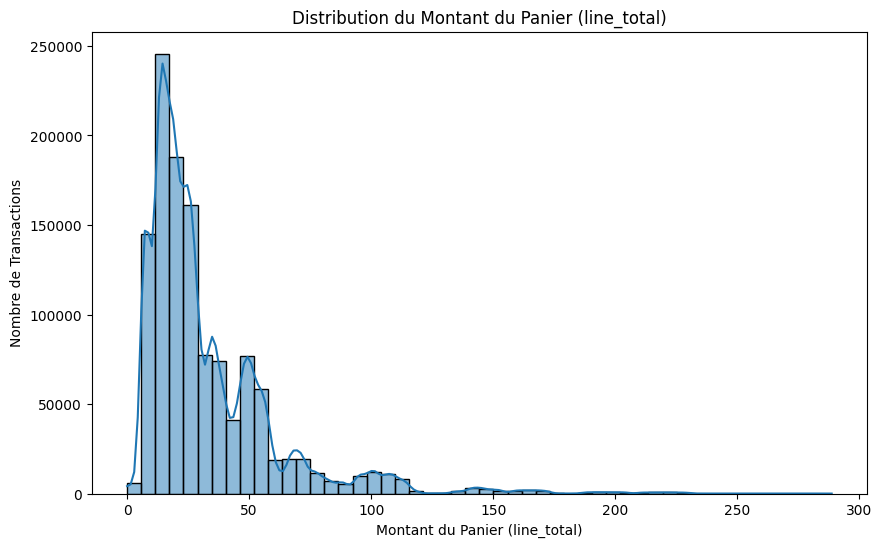

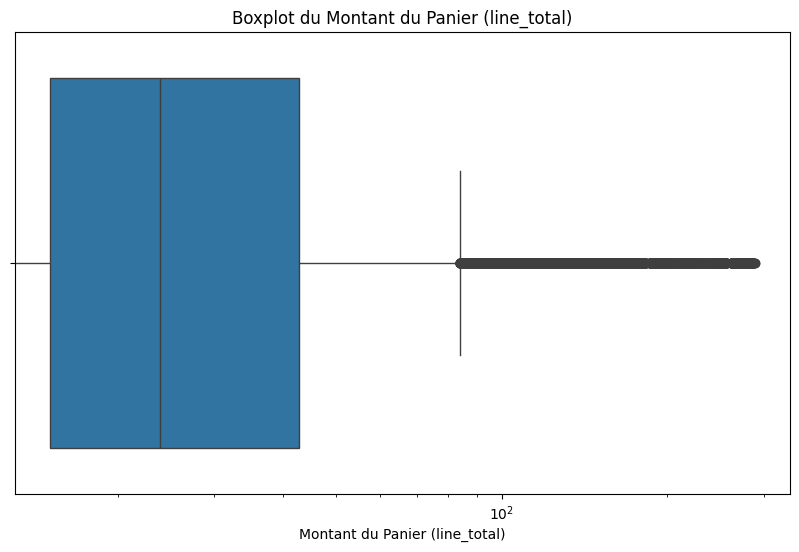

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Statistiques descriptives pour le 'line_total' :")
display(transactions_df_cleaned['line_total'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(transactions_df_cleaned['line_total'], bins=50, kde=True)
plt.title('Distribution du Montant du Panier (line_total)')
plt.xlabel('Montant du Panier (line_total)')
plt.ylabel('Nombre de Transactions')
plt.show()

# Boxplot pour mieux visualiser les outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=transactions_df_cleaned['line_total'])
plt.title('Boxplot du Montant du Panier (line_total)')
plt.xlabel('Montant du Panier (line_total)')
plt.xscale('log') # Utilisation d'une échelle logarithmique pour mieux voir les faibles valeurs
plt.show()

#### Distribution de la fréquence d'achat par client

Nous allons analyser la distribution de la fréquence d'achat, c'est-à-dire le nombre de commandes par client (`n_orders`), pour comprendre si la majorité des clients sont des acheteurs occasionnels ou récurrents. Cela nous aidera à évaluer la fidélité de la clientèle.

Statistiques descriptives pour le 'n_orders' (nombre de commandes par client) :


count    50295.000000
mean         4.586042
std          5.877529
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        373.000000
Name: n_orders, dtype: float64

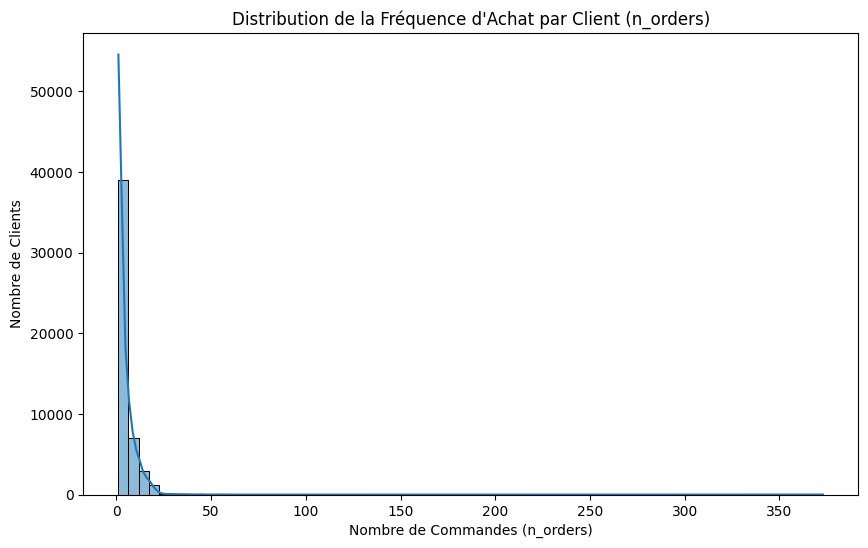

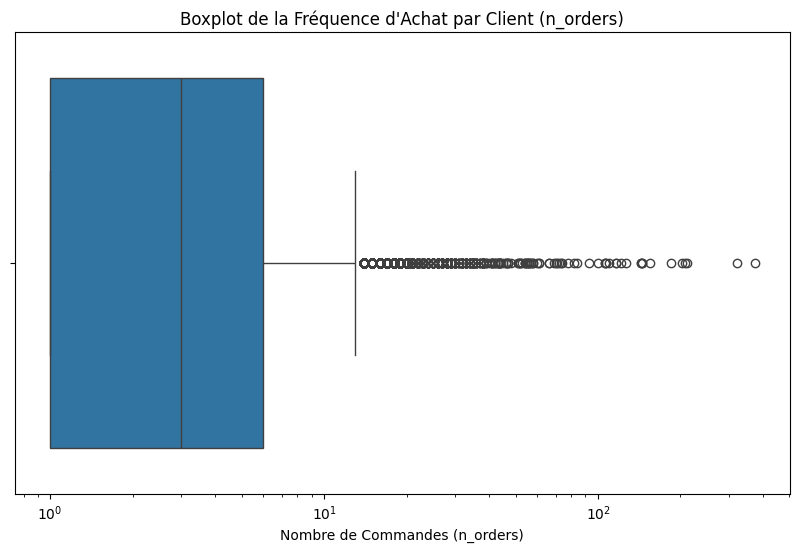

In [102]:
print("Statistiques descriptives pour le 'n_orders' (nombre de commandes par client) :")
display(customers_df_cleaned['n_orders'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(customers_df_cleaned['n_orders'], bins=70, kde=True)
plt.title('Distribution de la Fréquence d\'Achat par Client (n_orders)')
plt.xlabel('Nombre de Commandes (n_orders)')
plt.ylabel('Nombre de Clients')
plt.show()

# Boxplot pour mieux visualiser les outliers de la fréquence
plt.figure(figsize=(10, 6))
sns.boxplot(x=customers_df_cleaned['n_orders'])
plt.title('Boxplot de la Fréquence d\'Achat par Client (n_orders)')
plt.xlabel('Nombre de Commandes (n_orders)')
plt.xscale('log') # Utilisation d'une échelle logarithmique pour mieux voir les faibles valeurs
plt.show()

In [103]:
### Robustesse : mêmes stats n_orders après retrait des 10 % de plus fortes fréquences
seuil_p90 = customers_df_cleaned['n_orders'].quantile(0.995)
n_orders_sans_top10 = customers_df_cleaned.loc[
    customers_df_cleaned['n_orders'] <= seuil_p90, 'n_orders'
]
n_retires = customers_df_cleaned.shape[0] - n_orders_sans_top10.shape[0]

print(f"Seuil (90e centile de n_orders) : {seuil_p90:.0f} commandes")
print(f"Clients retirés (n_orders > {seuil_p90:.0f}) : {n_retires:,} "
      f"({n_retires / customers_df_cleaned.shape[0] * 100:.1f}%)")
print("\nStatistiques descriptives pour le 'n_orders' sans les 10 % plus gros :")
display(n_orders_sans_top10.describe())

print("\nPour comparaison, les clients retirés :")
display(customers_df_cleaned.loc[customers_df_cleaned['n_orders'] > seuil_p90, 'n_orders'].describe())


Seuil (90e centile de n_orders) : 23 commandes
Clients retirés (n_orders > 23) : 233 (0.5%)

Statistiques descriptives pour le 'n_orders' sans les 10 % plus gros :


count    50062.000000
mean         4.386421
std          4.195245
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max         23.000000
Name: n_orders, dtype: float64


Pour comparaison, les clients retirés :


count    233.000000
mean      47.476395
std       42.837309
min       24.000000
25%       28.000000
50%       34.000000
75%       46.000000
max      373.000000
Name: n_orders, dtype: float64

In [118]:
# Nettoyage : retirer le 1 % de plus gros montants (total_spent) pour écarter le B2B
n_avant = customers_df_cleaned.shape[0]
seuil_montant_p99 = customers_df_cleaned['total_spent'].quantile(0.99)

print("Statistiques descriptives pour le 'total_spent' avant retrait du top 1 % :")
display(customers_df_cleaned['total_spent'].describe())
print(f"\nSeuil (99e centile de total_spent) : {seuil_montant_p99:,.2f} €")

masque_b2b = customers_df_cleaned['total_spent'] > seuil_montant_p99
n_retires = int(masque_b2b.sum())
print(f"Clients retirés (total_spent > seuil) : {n_retires:,} ({n_retires / n_avant * 100:.2f}%)")

print("\nClients retirés — n_orders et total_spent :")
display(customers_df_cleaned.loc[masque_b2b, ['n_orders', 'total_spent']].describe())

customers_df_cleaned = customers_df_cleaned.loc[~masque_b2b].copy()

print(f"\nNouveau nombre de clients : {customers_df_cleaned.shape[0]:,}")
print("Statistiques descriptives pour le 'total_spent' après retrait du top 1 % :")
display(customers_df_cleaned['total_spent'].describe())
print("\nStatistiques descriptives pour le 'n_orders' après ce filtre :")
display(customers_df_cleaned['n_orders'].describe())


Statistiques descriptives pour le 'total_spent' avant retrait du top 1 % :


count    50043.000000
mean      3143.418854
std       4115.548292
min          5.370000
25%        633.250000
50%       1583.750000
75%       3891.975000
max      30246.870000
Name: total_spent, dtype: float64


Seuil (99e centile de total_spent) : 20,186.64 €
Clients retirés (total_spent > seuil) : 501 (1.00%)

Clients retirés — n_orders et total_spent :


,n_orders,total_spent
count,501.000000,501.000000
mean,15.828343,23991.841557
std,11.920171,2788.119497
min,5.000000,20189.370000
25%,10.000000,21534.920000
50%,13.000000,23473.380000
75%,17.000000,26062.440000
max,110.000000,30246.870000



Nouveau nombre de clients : 49,542
Statistiques descriptives pour le 'total_spent' après retrait du top 1 % :


count    49542.000000
mean      2932.586434
std       3548.310390
min          5.370000
25%        626.370000
50%       1556.680000
75%       3778.680000
max      20182.860000
Name: total_spent, dtype: float64


Statistiques descriptives pour le 'n_orders' après ce filtre :


count    49542.000000
mean         4.339954
std          4.394466
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        116.000000
Name: n_orders, dtype: float64

#### Loi de Pareto (règle des 80/20) : Proportion de clients générant 80% du chiffre d'affaires

Nous allons calculer la proportion de clients qui contribuent à 80% du `total_spent` global. Cela permettra d'identifier les clients à haute valeur et de vérifier si la règle des 80/20 s'applique à nos données.

In [105]:
# Calculer le chiffre d'affaires total
total_revenue = customers_df_cleaned['total_spent'].sum()

# Trier les clients par total_spent de manière décroissante
customers_sorted_by_spent = customers_df_cleaned.sort_values(by='total_spent', ascending=False).reset_index(drop=True)

# Calculer le cumul des dépenses
customers_sorted_by_spent['cumulative_spent'] = customers_sorted_by_spent['total_spent'].cumsum()

# Calculer le seuil de 80% du chiffre d'affaires total
threshold_80_percent_revenue = total_revenue * 0.8

# Identifier la proportion de clients qui atteignent ce seuil
customers_for_80_percent_revenue = customers_sorted_by_spent[
    customers_sorted_by_spent['cumulative_spent'] <= threshold_80_percent_revenue
].shape[0]

proportion_customers_80_percent_revenue = (customers_for_80_percent_revenue / total_customers) * 100

print(f"Chiffre d'affaires total : {total_revenue:,.2f}€")
print(f"80% du chiffre d'affaires total : {threshold_80_percent_revenue:,.2f}€")
print(f"Nombre de clients pour atteindre 80% du chiffre d'affaires : {customers_for_80_percent_revenue}")
print(f"Proportion de clients générant 80% du chiffre d'affaires : {proportion_customers_80_percent_revenue:.2f}%")

Chiffre d'affaires total : 157,306,109.72€
80% du chiffre d'affaires total : 125,844,887.78€
Nombre de clients pour atteindre 80% du chiffre d'affaires : 17950
Proportion de clients générant 80% du chiffre d'affaires : 35.69%


#### Lecture de la loi de Pareto

**Observation :** environ **34 % des clients** génèrent **80 % du chiffre d'affaires**. La concentration est réelle, mais moins extrême que le 80/20 classique : le top 10 % des clients porte déjà près de 45 % du CA, et le top 20 % environ 64 %.

**Implication marketing :** une petite tête de file (VIP) mérite un traitement CRM dédié, mais une large "classe moyenne" contribue encore beaucoup. Couper trop tôt le budget sur les clients "moyens" ferait perdre une part importante du CA. Cette polarisation sera le premier axe de la segmentation RFM du Jour 2.

---

#### Saisonnalité : évolution du chiffre d'affaires mensuel

Nous allons agréger le `line_total` par mois pour identifier les pics saisonniers et en déduire un calendrier de campagnes.


Chiffre d'affaires mensuel (extrait) :


,invoice_month,revenue
0,2022-01-01,14.98
1,2022-02-01,7.81
2,2022-03-01,175.09
3,2022-04-01,619.14
4,2022-05-01,1452.55
5,2022-06-01,1585.36
6,2022-07-01,1952.13
7,2022-08-01,1615.34
8,2022-09-01,4102.85
9,2022-10-01,5316.96


...


,invoice_month,revenue
42,2025-07-01,1085349.49
43,2025-08-01,1284203.33
44,2025-09-01,1301484.17
45,2025-10-01,1481481.83
46,2025-11-01,1362847.94
47,2025-12-01,1493838.59
48,2026-01-01,1462682.10
49,2026-02-01,1403129.65
50,2026-03-01,1546795.60
51,2026-04-01,2046098.86


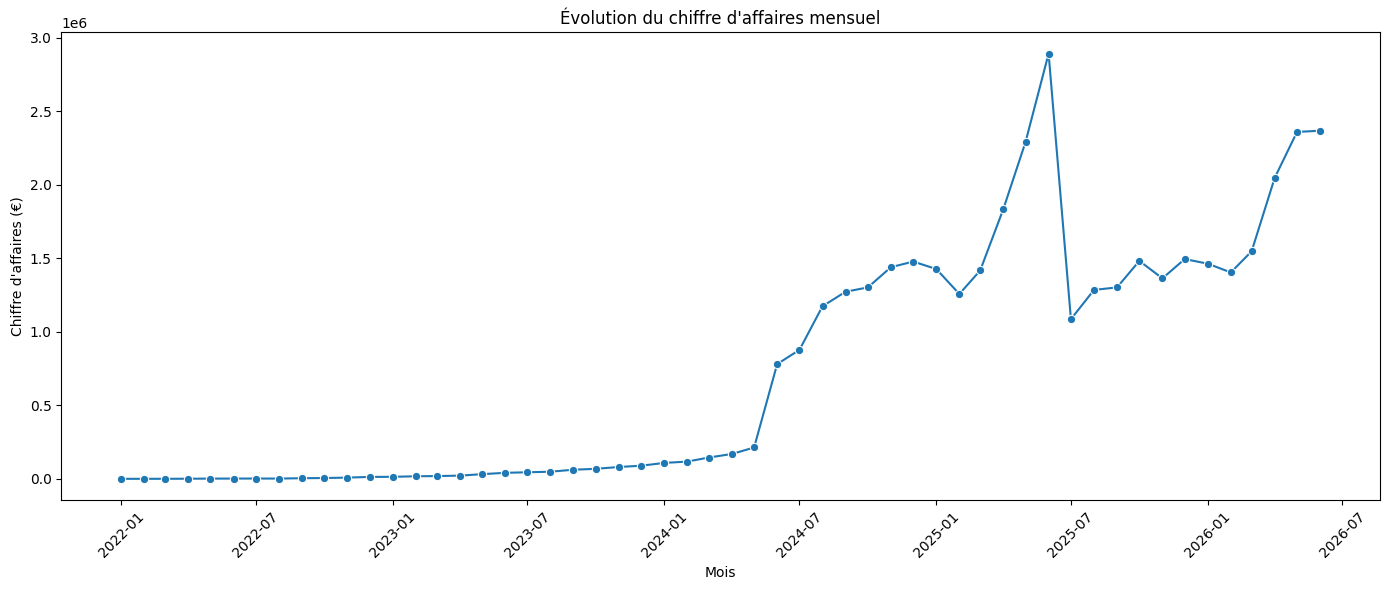


Chiffre d'affaires 2025 par mois calendaire :


month
1     1426257.03
2     1256490.39
3     1416362.76
4     1832228.09
5     2290426.01
6     2890954.88
7     1085349.49
8     1284203.33
9     1301484.17
10    1481481.83
11    1362847.94
12    1493838.59
Name: line_total, dtype: float64

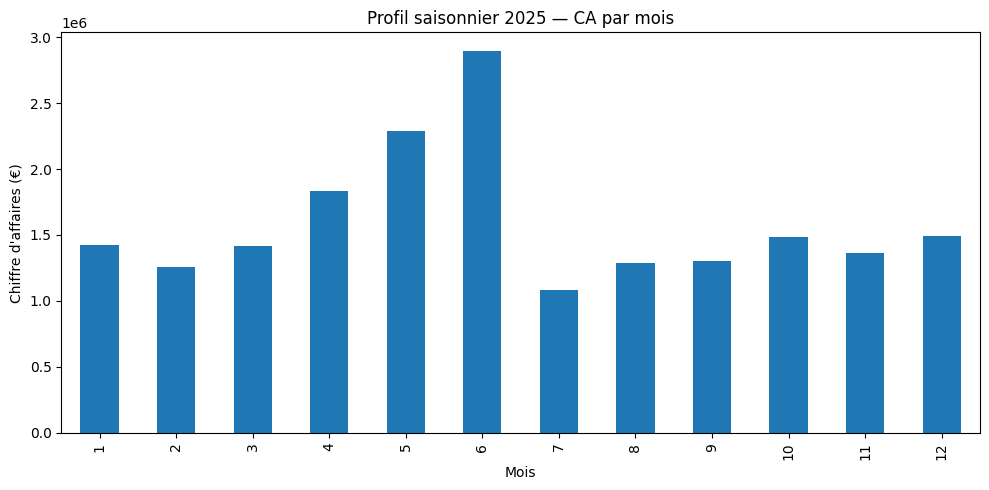


Mois le plus fort (2025) : 6 (2,890,955 €)
Mois le plus faible (2025) : 7 (1,085,349 €)


In [106]:
# Évolution mensuelle du chiffre d'affaires
tx_season = transactions_df_cleaned.copy()
tx_season['invoice_month'] = tx_season['invoice_date'].dt.to_period('M').dt.to_timestamp()

monthly_revenue = (
    tx_season.groupby('invoice_month', as_index=False)['line_total']
    .sum()
    .rename(columns={'line_total': 'revenue'})
)

print("Chiffre d'affaires mensuel (extrait) :")
display(monthly_revenue.head(12))
print("...")
display(monthly_revenue.tail(12))

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x='invoice_month', y='revenue', marker='o')
plt.title("Évolution du chiffre d'affaires mensuel")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Profil saisonnier une fois la marque à maturité (2025, année complète)
tx_2025 = tx_season[tx_season['invoice_date'].dt.year == 2025].copy()
tx_2025['month'] = tx_2025['invoice_date'].dt.month
revenue_2025_by_month = tx_2025.groupby('month')['line_total'].sum()

print("\nChiffre d'affaires 2025 par mois calendaire :")
display(revenue_2025_by_month)

plt.figure(figsize=(10, 5))
revenue_2025_by_month.plot(kind='bar')
plt.title("Profil saisonnier 2025 — CA par mois")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.tight_layout()
plt.show()

print("\nMois le plus fort (2025) :", int(revenue_2025_by_month.idxmax()),
      f"({revenue_2025_by_month.max():,.0f} €)")
print("Mois le plus faible (2025) :", int(revenue_2025_by_month.idxmin()),
      f"({revenue_2025_by_month.min():,.0f} €)")


#### Lecture de la saisonnalité

**Observations :**
- La série mensuelle montre une **montée en puissance 2022–2024** (cohérente avec le récit de croissance de Lumina), puis un **palier de volume élevé en 2025–2026**.
- Sur l'année 2025 (la plus lisible saisonnièrement), le CA **pic en avril–juin**, avec un **maximum en juin**, puis un **creux net en juillet**. L'automne-hiver (nov–déc) existe mais n'est **pas** le pic principal — contrairement à beaucoup d'e-commerces généralistes.
- Ce profil colle à une marque cosmétique DTC : rituel corps / été, fête des mères, lancements "slow beauty" au printemps ; juillet correspond aux vacances et à une baisse d'attention digitale.

**Implications campagnes :**
- Concentrer les pushes **Corps / Coffrets / acquisition** en **mars–mai**, avant le pic.
- Prévoir un **winback / relance post-soldes** en juillet–août, quand le CA retombe.
- Noël reste un relais, pas le cœur du calendrier : plutôt des coffrets et rituels que du volume massif.

---

#### Géographie : répartition des clients et biais de la base

Nous comparons le poids de chaque pays (nombre de clients et CA) et les comportements d'achat (panier moyen, fréquence). Le point de vigilance du brief est explicite : un pays surreprésenté biaise les segments RFM de demain.


Top 15 pays par nombre de clients :


,n_clients,total_spent,avg_basket,avg_orders,median_spent,pct_clients,pct_ca
country,,,,,,,
France,45661,1.431826e+08,705.00,4.49,1568.14,91.24,91.02
Germany,914,3.329143e+06,804.97,4.91,2091.72,1.83,2.12
United Kingdom,758,2.685275e+06,730.03,4.71,1410.86,1.51,1.71
Spain,291,8.410860e+05,788.80,3.39,1507.99,0.58,0.53
Portugal,211,7.398112e+05,845.20,3.58,1875.03,0.42,0.47
Belgium,203,6.651600e+05,644.35,5.65,2132.34,0.41,0.42
Switzerland,184,9.016999e+05,1414.67,3.97,3654.73,0.37,0.57
Sweden,171,2.403460e+05,852.76,2.64,1224.20,0.34,0.15
Netherlands,165,2.669494e+05,575.56,3.18,1309.50,0.33,0.17



France : 91.2% des clients, 91.0% du CA
Nombre de pays distincts : 41


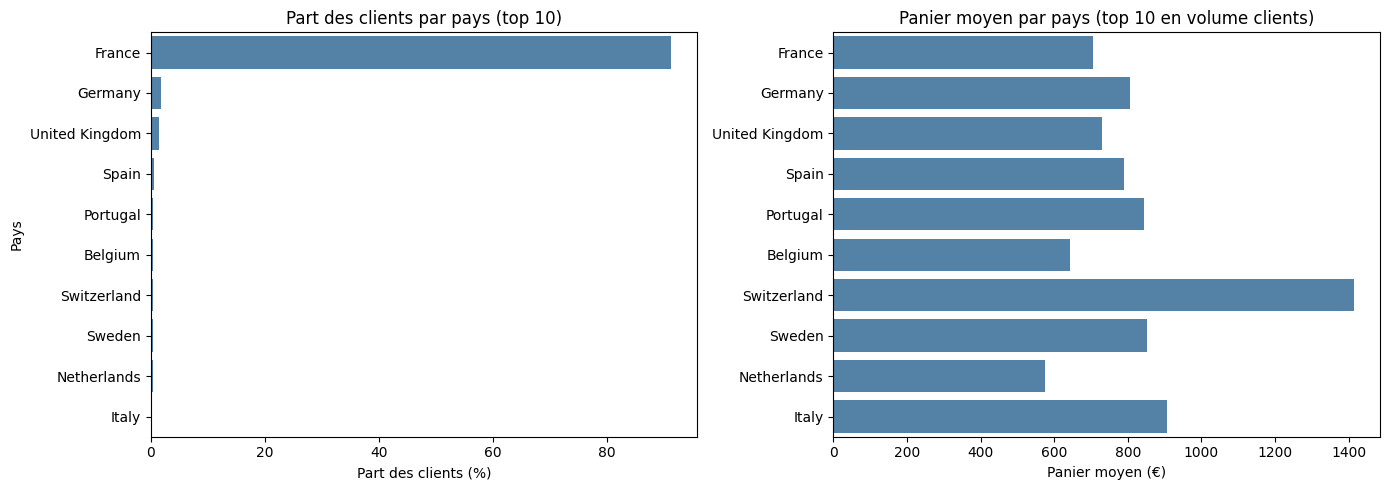


Pays avec une fréquence d'achat atypique (avg_orders > 10) :


,n_clients,total_spent,avg_basket,avg_orders,median_spent,pct_clients,pct_ca
country,,,,,,,
EIRE,12,164767.3,1209.31,11.42,13771.61,0.02,0.1


In [107]:
geo = (
    customers_df_cleaned.groupby('country')
    .agg(
        n_clients=('customer_id', 'count'),
        total_spent=('total_spent', 'sum'),
        avg_basket=('avg_basket', 'mean'),
        avg_orders=('n_orders', 'mean'),
        median_spent=('total_spent', 'median'),
    )
    .sort_values('n_clients', ascending=False)
)
geo['pct_clients'] = geo['n_clients'] / geo['n_clients'].sum() * 100
geo['pct_ca'] = geo['total_spent'] / geo['total_spent'].sum() * 100

print("Top 15 pays par nombre de clients :")
display(geo.head(15).round(2))

print(f"\nFrance : {geo.loc['France', 'pct_clients']:.1f}% des clients, "
      f"{geo.loc['France', 'pct_ca']:.1f}% du CA")
print(f"Nombre de pays distincts : {geo.shape[0]}")

top10 = geo.head(10).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=top10, x='pct_clients', y='country', ax=axes[0], color='steelblue')
axes[0].set_title("Part des clients par pays (top 10)")
axes[0].set_xlabel("Part des clients (%)")
axes[0].set_ylabel("Pays")
sns.barplot(data=top10, x='avg_basket', y='country', ax=axes[1], color='steelblue')
axes[1].set_title("Panier moyen par pays (top 10 en volume clients)")
axes[1].set_xlabel("Panier moyen (€)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

print("\nPays avec une fréquence d'achat atypique (avg_orders > 10) :")
display(geo[geo['avg_orders'] > 10].round(2))


#### Lecture géographique — limite à mentionner en présentation

**Biais structurel :** la **France représente ~91 % des clients et ~91 % du CA**. Allemagne et Royaume-Uni suivent très loin (~1,5–2 %). Tous les autres pays pèsent chacun moins de 1 % des clients.

**Comportements :**
- Le panier moyen et la fréquence varient (Suisse, Norvège, Grèce : paniers plus élevés) mais ces écarts reposent sur de **très petits effectifs** : ils ne sont pas assez stables pour créer des segments pays.
- Quelques pays (notamment **EIRE**) ont une fréquence moyenne hors norme (des dizaines de commandes par client) : signal classique de **comptes B2B / wholesale**, pas de clients DTC individuels.

**Point de vigilance (Jour 2) :** les clusters RFM seront **des clusters France**. Un "segment international" collerait ensemble des réalités hétérogènes (wholesale irlandais, petits comptes asiatiques, etc.). Documenter ce biais comme limite de la segmentation.

---

#### Relations entre variables (récence, fréquence, montant)

Trois questions : la récence est-elle liée linéairement au montant dépensé ? Les clients fréquents ont-ils un panier plus élevé ? Voit-on déjà des groupes naturels avant clustering ?


Corrélations (Pearson et Spearman) :


,pearson,spearman
recency vs total_spent,-0.349,-0.445
n_orders vs avg_basket,-0.015,0.083
n_orders vs total_spent,0.674,0.757
recency vs n_orders,-0.397,-0.515


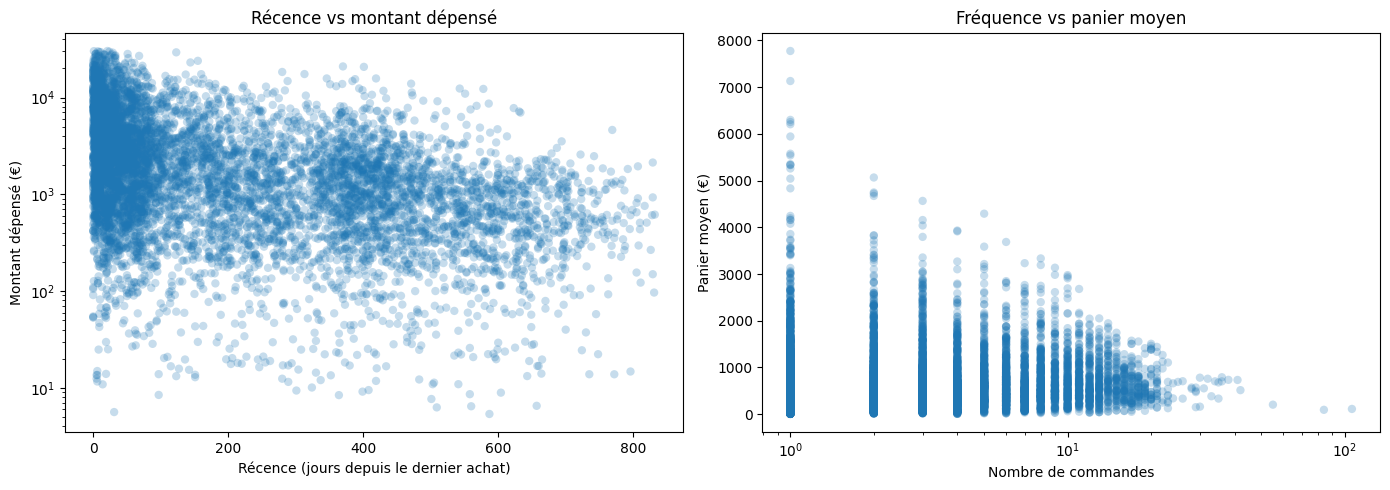


Panier moyen et CA selon la fréquence :


,n_clients,avg_basket,mean_total_spent,mean_recency
freq_bin,,,,
1 commande,14460,708.1,708.1,352.2
2-3,14846,717.8,1754.4,215.3
4-6,9621,719.0,3464.7,139.7
7-20,10740,728.5,7716.0,71.1
21+,376,480.2,12815.5,29.8



CA et fréquence selon le quartile de récence :


,n_clients,mean_total_spent,mean_n_orders
recency_q,,,
"(-0.001, 29.0]",12759,5313.6,7.2
"(29.0, 111.0]",12301,3715.5,5.2
"(111.0, 377.0]",12486,2225.2,3.4
"(377.0, 846.0]",12497,1282.1,2.0


In [108]:
print("Corrélations (Pearson et Spearman) :")
corr_table = pd.DataFrame({
    'pearson': [
        customers_df_cleaned['recency_days'].corr(customers_df_cleaned['total_spent']),
        customers_df_cleaned['n_orders'].corr(customers_df_cleaned['avg_basket']),
        customers_df_cleaned['n_orders'].corr(customers_df_cleaned['total_spent']),
        customers_df_cleaned['recency_days'].corr(customers_df_cleaned['n_orders']),
    ],
    'spearman': [
        customers_df_cleaned['recency_days'].corr(customers_df_cleaned['total_spent'], method='spearman'),
        customers_df_cleaned['n_orders'].corr(customers_df_cleaned['avg_basket'], method='spearman'),
        customers_df_cleaned['n_orders'].corr(customers_df_cleaned['total_spent'], method='spearman'),
        customers_df_cleaned['recency_days'].corr(customers_df_cleaned['n_orders'], method='spearman'),
    ],
}, index=['recency vs total_spent', 'n_orders vs avg_basket',
          'n_orders vs total_spent', 'recency vs n_orders'])
display(corr_table.round(3))

# Échantillon pour les scatter plots (lisibilité)
sample = customers_df_cleaned.sample(n=min(8000, len(customers_df_cleaned)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=sample, x='recency_days', y='total_spent', alpha=0.25, ax=axes[0], edgecolor='none')
axes[0].set_title("Récence vs montant dépensé")
axes[0].set_xlabel("Récence (jours depuis le dernier achat)")
axes[0].set_ylabel("Montant dépensé (€)")
axes[0].set_yscale('log')

sns.scatterplot(data=sample, x='n_orders', y='avg_basket', alpha=0.25, ax=axes[1], edgecolor='none')
axes[1].set_title("Fréquence vs panier moyen")
axes[1].set_xlabel("Nombre de commandes")
axes[1].set_ylabel("Panier moyen (€)")
axes[1].set_xscale('log')
plt.tight_layout()
plt.show()

customers_rel = customers_df_cleaned.copy()
customers_rel['freq_bin'] = pd.cut(
    customers_rel['n_orders'],
    bins=[0, 1, 3, 6, 20, 10_000],
    labels=['1 commande', '2-3', '4-6', '7-20', '21+'],
)
print("\nPanier moyen et CA selon la fréquence :")
display(
    customers_rel.groupby('freq_bin', observed=True)
    .agg(
        n_clients=('customer_id', 'count'),
        avg_basket=('avg_basket', 'mean'),
        mean_total_spent=('total_spent', 'mean'),
        mean_recency=('recency_days', 'mean'),
    )
    .round(1)
)

customers_rel['recency_q'] = pd.qcut(customers_rel['recency_days'], 4, duplicates='drop')
print("\nCA et fréquence selon le quartile de récence :")
display(
    customers_rel.groupby('recency_q', observed=True)
    .agg(
        n_clients=('customer_id', 'count'),
        mean_total_spent=('total_spent', 'mean'),
        mean_n_orders=('n_orders', 'mean'),
    )
    .round(1)
)


#### Lecture des relations — segments déjà visibles

**Récence vs montant :** corrélation **négative**, plus forte en Spearman (~ -0,45) qu'en Pearson (~ -0,27). La relation est **monotone mais pas linéaire** : les clients très récents (quartile < ~1 mois) ont un CA moyen ~5× supérieur aux clients dormants (> ~1 an). Ce n'est pas "plus on attend, plus on dépense" : c'est "les gros contributeurs rachètent récemment, les petits s'éteignent".

**Fréquence vs panier moyen :** corrélation **quasi nulle** (~0,01 à 0,09). Les clients fréquents ne dépensent **pas plus par visite** (paniers ~700–760 € selon les bins, voire un peu plus bas chez les 21+). La valeur client vient du **nombre de visites**, pas d'un ticket plus gros. **F et M sont orthogonaux** : c'est exactement le cas où un score RFM à trois axes est utile, plutôt qu'un simple ranking sur le CA.

**Segments naturels, avant toute modélisation :**
1. **One-shot (~29 %)** vs **récurrents (~71 %)** — déjà mesuré en étape 2.
2. **Actifs récents à haute valeur** vs **dormants à faible valeur** (gradient de récence).
3. Une **queue B2B / wholesale** (très haute fréquence, quelques IDs à 100–300+ commandes).
4. Une **classe VIP** (top ~34 % du fichier) distincte d'une masse de petits paniers.

Le clustering du Jour 2 devra retrouver (et affiner) ces groupes, pas les inventer.

---

#### Catégories de produits : répartition du chiffre d'affaires

Premier regard par `category`, qui servira de point de comparaison au Jour 2 (affinité produit des segments RFM).


Répartition du CA par catégorie :


,ca_eur,pct_ca,n_lignes,pct_lignes
category,,,,
Visage,12749132.41,31.91,344257,28.31
Coffret,8315224.73,20.81,98225,8.08
Corps,8284291.87,20.74,288865,23.76
Cheveux,4501341.42,11.27,173786,14.29
Accessoire,3253444.38,8.14,164986,13.57
Bain,2833117.13,7.09,142475,11.72
Frais,12354.35,0.03,3279,0.27


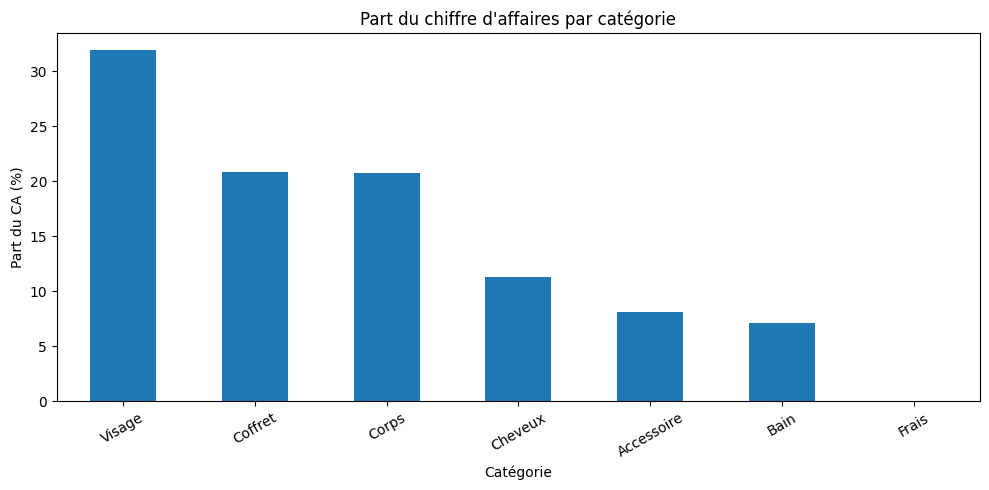

Catégorie dominante : Visage (31.9% du CA)
Top 3 cumulé : 73.5% du CA


In [109]:
cat_revenue = (
    transactions_df_cleaned.groupby('category', dropna=False)['line_total']
    .sum()
    .sort_values(ascending=False)
)
cat_share = (cat_revenue / cat_revenue.sum() * 100).rename('pct_ca')
cat_table = pd.DataFrame({
    'ca_eur': cat_revenue,
    'pct_ca': cat_share,
    'n_lignes': transactions_df_cleaned.groupby('category', dropna=False).size(),
})
cat_table['pct_lignes'] = cat_table['n_lignes'] / cat_table['n_lignes'].sum() * 100
cat_table = cat_table.sort_values('ca_eur', ascending=False)

print("Répartition du CA par catégorie :")
display(cat_table.round(2))

plt.figure(figsize=(10, 5))
cat_share.plot(kind='bar')
plt.title("Part du chiffre d'affaires par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Part du CA (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"Catégorie dominante : {cat_revenue.index[0]} ({cat_share.iloc[0]:.1f}% du CA)")
print(f"Top 3 cumulé : {cat_share.iloc[:3].sum():.1f}% du CA")


#### Lecture des catégories

**Observation :** **Visage** est en tête (~32 % du CA), suivi de **Coffret** et **Corps** (~21 % chacun). Cheveux, Accessoire et Bain se partagent le reste. La catégorie `Frais` (frais de port / ajustements résiduels) est négligeable.

La répartition n'est **pas monopolistique** : trois familles portent ~75 % du CA. Les **coffrets sur-indexent en valeur** par rapport à leur nombre de lignes (panier plus élevé), ce qui en fait un levier naturel de montée en gamme.

**Pour le Jour 2 :** on pourra tester si les VIP / récurrents sur-achètent les coffrets, et si les one-shot restent cantonnés au Visage (produit d'entrée). C'est l'affinité produit par segment.

---

#### Données zero-party (`customers.csv`)

Les colonnes `declared_preference`, `age_bracket`, `life_stage` et `urban_density` sont déclaratives (le client les a renseignées). On mesure le taux de remplissage — et on le compare à ce qu'on attend d'une donnée zero-party.


Taux de remplissage des variables zero-party :


,colonne,n_renseignes,taux_remplissage_pct,taux_manquant_pct
0,declared_preference,19089,38.1,61.9
1,age_bracket,21361,42.7,57.3
2,life_stage,11258,22.5,77.5
3,urban_density,9907,19.8,80.2



Au moins une variable renseignée : 78.0%
Les 4 variables renseignées : 0.7%
Aucune variable renseignée : 22.0%


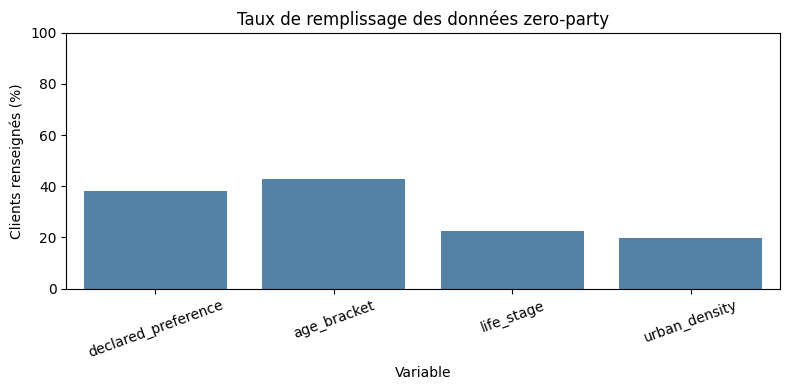


Modalités observées (hors NaN) :

declared_preference :


declared_preference
Peau sensible         2797
Anti-imperfections    2754
Anti-âge              2748
Recherche vegan       2743
Peau mixte            2702
Peau sèche            2681
Sans parfum           2664
Name: count, dtype: int64


age_bracket :


age_bracket
18-24 ans         4362
35-44 ans         4296
25-34 ans         4269
45-54 ans         4220
55 ans et plus    4214
Name: count, dtype: int64


life_stage :


life_stage
Parent de jeunes enfants    2329
Famille avec adolescents    2272
Sans enfants                2243
Jeune actif en solo         2216
Retraité(e)                 2198
Name: count, dtype: int64


urban_density :


urban_density
Zone urbaine dense    3347
Périurbain            3347
Zone rurale           3213
Name: count, dtype: int64

In [110]:
zp_cols = ['declared_preference', 'age_bracket', 'life_stage', 'urban_density']
n_customers = customers_df_cleaned.shape[0]

fill_rows = []
for col in zp_cols:
    n_filled = customers_df_cleaned[col].notna().sum()
    fill_rows.append({
        'colonne': col,
        'n_renseignes': n_filled,
        'taux_remplissage_pct': n_filled / n_customers * 100,
        'taux_manquant_pct': (n_customers - n_filled) / n_customers * 100,
    })
fill_df = pd.DataFrame(fill_rows)
print("Taux de remplissage des variables zero-party :")
display(fill_df.round(1))

any_filled = customers_df_cleaned[zp_cols].notna().any(axis=1).mean() * 100
all_filled = customers_df_cleaned[zp_cols].notna().all(axis=1).mean() * 100
none_filled = (~customers_df_cleaned[zp_cols].notna().any(axis=1)).mean() * 100
print(f"\nAu moins une variable renseignée : {any_filled:.1f}%")
print(f"Les 4 variables renseignées : {all_filled:.1f}%")
print(f"Aucune variable renseignée : {none_filled:.1f}%")

plt.figure(figsize=(8, 4))
sns.barplot(data=fill_df, x='colonne', y='taux_remplissage_pct', color='steelblue')
plt.title("Taux de remplissage des données zero-party")
plt.xlabel("Variable")
plt.ylabel("Clients renseignés (%)")
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

print("\nModalités observées (hors NaN) :")
for col in zp_cols:
    print(f"\n{col} :")
    display(customers_df_cleaned[col].value_counts(dropna=True))


#### Lecture des données zero-party

**Taux de remplissage :**
- `age_bracket` ~43 %, `declared_preference` ~38 %, `life_stage` ~22 %, `urban_density` ~20 %.
- 78 % des clients ont **au moins un** champ ; seulement ~1 % ont les **quatre** ; ~22 % n'ont **rien**.

**Est-ce cohérent avec de la zero-party ?** Oui. Une donnée zero-party est **volontaire, déclarative et rarement complète**. Des taux à 20–40 % (et un quasi-vide sur le profil "complet") sont normaux : on n'a pas un CRM socio-démo exhaustif, on a un **questionnaire opt-in**. Conséquences :
- Biais de répondants (ceux qui déclarent une préférence "Peau sensible" / "Recherche vegan" ne sont pas un échantillon aléatoire).
- Impossible d'en faire **la** segmentation principale : trop de manquants.
- En revanche, c'est un **excellent overlay** sur un segment RFM (personnaliser l'objet d'email une fois le segment comportemental posé).

---

## Étape 4 : Hypothèses marketing (à tester au Jour 2)

Ces hypothèses relient une observation d'EDA à un comportement attendu, puis à une action. La segmentation RFM / le clustering devront les valider ou les invalider.

> **H1 — One-shot vs récurrents.** Je suppose que les **29 % de clients à une seule commande**, plus anciens en récence, impliquent un comportement d'**essai non converti en habitude**, ce qui suggère un **scénario d'onboarding / 2e commande** (offre rituel + échantillon) distinct des emails envoyés aux récurrents.

> **H2 — VIP et concentration.** Je suppose que le fait que **~34 % des clients portent 80 % du CA** implique un cœur de clientèle **fidèle et à haute valeur**, ce qui suggère un **programme VIP** (accès anticipé coffrets, SAV prioritaire) plutôt qu'une campagne unique "à tout le monde".

> **H3 — Fréquence et panier sont indépendants.** Je suppose que la **corrélation nulle entre n_orders et avg_basket** implique deux leviers séparés (faire revenir vs faire monter le ticket), ce qui suggère des **offres différentes** : relance / abonnement pour les fréquents à petit panier, et **upsell coffret** pour les peu fréquents à fort panier.

> **H4 — Calendrier et mix produit.** Je suppose que le **pic avril–juin** et le poids de **Visage + Corps + Coffret** impliquent un rituel saisonnier (corps d'été, fête des mères), ce qui suggère d'**avancer les campagnes en mars** et de tester, au Jour 2, si les VIP sur-indexent vraiment sur les coffrets.

> **H5 — Limites de la future segmentation.** Je suppose que le **biais France (~91 %)** et le **faible remplissage zero-party** impliquent des segments RFM **dominés par le marché français** et peu informés par l'âge / le life stage, ce qui suggère de **documenter ce biais** en présentation et d'utiliser la zero-party seulement en **personnalisation secondaire**, pas comme axe de clustering.

---

### Rappel — décisions de nettoyage (pour le livrable)

| Problème | Décision | Pourquoi |
|---|---|---|
| `customer_id` manquant | Isoler puis retirer du fichier client | Lignes internes (frais, échantillons, ajustements), pas des clients CRM |
| `quantity` < 0 | Supprimer | Retours / avoirs : fausseraient CA, fréquence et RFM |
| `unit_price` = 0 | Garder les vrais produits (promos), supprimer les codes non-produits (`M`, `POST`, `D`, `CRUK`, `S`) | Distinguer cadeau marketing et écriture comptable |
| `line_total` | `quantity × unit_price` ; retirer les totaux négatifs résiduels (remises) | Base de CA cohérente |
| Dates clients | `first_purchase` ≤ `last_purchase` contrôlé | Pas d'inversion bloquante |
| One-shot vs récurrents | 28,8 % / 71,3 % | Premier cut comportemental, avant RFM |


---

# TP2 - Segmentation RFM & Lumina & Co

#### Contexte

Vous avez maintenant une base propre. Le CMO attend une réponse à sa question : *"Qui sont nos clients ?"* Pas en termes démographiques vagues, mais en segments actionnables avec des recommandations concrètes.

#### Étape 1 : Construction des features RFM

À partir de `transactions.csv` nettoyé, calculez pour chaque client :

- **Récence** : nombre de jours entre son dernier achat et la date de référence (date max du dataset)
- **Fréquence** : nombre de factures distinctes sur la période complète
- **Montant** : somme totale des `line_total` sur la période complète

La date de référence doit être fixée une fois pour toutes, c'est le *"snapshot date"*. Utiliser la date du jour serait une erreur : les données ne vont pas jusqu'à aujourd'hui.

Enrichissez si vous le souhaitez avec une ou deux features simples supplémentaires (panier moyen, ancienneté), sans obligation d'en faire une liste exhaustive.

#### Étape 2 : Scoring RFM et segments

Attribuez les scores R, F, M de 1 à 5 par quintiles. Créez les segments RFM et répondez :

- Combien de *"Champions"* (score 555 ou proche) ? Quelle part du CA représentent-ils ?
- Combien de clients *"À risque"* (forte valeur historique, faible récence) ?
- Quelle proportion de la base est *"Perdue"* (111) ? Quelle action pour ce segment ?

Ces trois questions ne couvrent que les cas extrêmes. La majorité de vos clients ne collera à aucun de ces trois profils. Une fois ces 3 segments identifiés, comment amélioreriez-vous la segmentation pour couvrir le reste de la base ? Définissez vos propres règles par plage, documentez vos seuils, et justifiez pourquoi vous les avez placés à cet endroit plutôt qu'un autre s'il y a une raison.

Visualisez la distribution des scores et la matrice RFM

#### Étape 3 : Visualisation et profilage

- Profil démographique de chaque segment (pays, ancienneté)
- Scatter plot récence × montant, coloré par segment

> Attention à la relation non linéaire entre récence et valeur : des clients très récents et très anciens peuvent tous deux avoir un fort potentiel

#### Étape 4 : Recommandations marketing par segment

Pour chacun des 5 à 8 segments obtenus, rédigez une fiche :

- Qui sont-ils (profil comportemental)
- Leur potentiel (valeur actuelle et potentielle)
- Le risque (churn, inactivité)
- L'action recommandée (campagne email, offre, exclusion des campagnes coûteuses...)

Puis, classez vos segments par ordre de priorité de traitement (1 = à traiter en premier). Pour chaque rang, nommez explicitement le critère qui justifie cet ordre (valeur, risque de perte, potentiel de croissance). Vérifiez enfin que le temps ou le budget que vous consacreriez réellement à chaque segment reflète bien cet ordre : si vos segments classés 1 et 4 recevraient le même traitement dans la pratique, votre priorisation n'est que théorique.

Si vous le souhaitez, ajoutez une métrique de succès par segment (ex : taux de réactivation, commandes dans les 30 jours suivants). Ce n'est pas obligatoire à ce stade, mais bienvenu si vous avez le temps.

> **Pour aller plus loin :** le scoring par quintiles suppose une base assez grande pour que "20% des clients" ait un sens. Réfléchissez à comment vous adapteriez cette méthode sur une base de 50 clients seulement, par exemple celle d'un auto-entrepreneur. Quels paliers fixeriez-vous à la main ?

> **Pour aller plus loin :** segmentation insight-driven. Le RFM segmente sur le comportement d'achat (combien, quand, à quelle fréquence), pas sur qui est le client ni pourquoi il achète. `customers.csv` contient 4 colonnes de préférences déclarées via un quiz de bienvenue (`declared_preference`, `age_bracket`, `life_stage`, `urban_density`), sparse mais exploitables sur le sous-ensemble de clients qui y ont répondu.

- Choisissez un de vos segments RFM et croisez-le avec un des champs zero-party disponibles
- Le croisement révèle-t-il un profil plus précis que le RFM seul ?
- Si oui, comment ça changerait le message ou le canal utilisé pour les activer, par rapport à une action RFM générique ?




### TP2 — mise en œuvre

Les cellules ci-dessous construisent le RFM **à partir de `transactions_df_cleaned`** (pas des agrégats CRM), scorent par quintiles, nomment 8 segments, puis profilent et priorisent les actions.


#### Étape 1 : Construction des features RFM

On fixe un **snapshot date** unique : la date max des factures nettoyées. La récence est le nombre de jours entre le dernier achat du client et ce snapshot — pas la date du jour.


In [111]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Snapshot = dernière facture du fichier nettoyé (pas datetime.now())
snapshot_date = transactions_df_cleaned['invoice_date'].max()
print(f"Snapshot date : {snapshot_date}")
print(f"Période : {transactions_df_cleaned['invoice_date'].min()} → {snapshot_date}")

rfm_df = (
    transactions_df_cleaned
    .groupby('customer_id')
    .agg(
        last_purchase=('invoice_date', 'max'),
        first_purchase=('invoice_date', 'min'),
        frequency=('invoice_id', 'nunique'),
        monetary=('line_total', 'sum'),
        country=('country', 'first'),
    )
    .reset_index()
)

rfm_df['recency'] = (snapshot_date - rfm_df['last_purchase']).dt.days
rfm_df['tenure_days'] = (rfm_df['last_purchase'] - rfm_df['first_purchase']).dt.days
rfm_df['avg_basket'] = rfm_df['monetary'] / rfm_df['frequency']

print(f"\nClients RFM : {len(rfm_df):,}")
print("\nStatistiques RFM (+ panier moyen, ancienneté) :")
display(rfm_df[['recency', 'frequency', 'monetary', 'avg_basket', 'tenure_days']].describe().round(2))


Snapshot date : 2026-06-30 00:00:00
Période : 2022-01-07 00:00:00 → 2026-06-30 00:00:00

Clients RFM : 49,204

Statistiques RFM (+ panier moyen, ancienneté) :


,recency,frequency,monetary,avg_basket,tenure_days
count,49204.00,49204.00,49204.00,49204.00,49204.00
mean,312.03,4.38,811.90,154.10,227.14
std,295.35,5.77,4162.57,305.31,229.67
min,0.00,1.00,0.00,0.00,0.00
25%,72.00,1.00,100.95,53.69,0.00
50%,207.00,3.00,242.26,77.91,162.00
75%,489.00,6.00,568.57,111.96,416.00
max,1635.00,379.00,416466.04,9879.18,823.00


#### Lecture — features RFM

**Snapshot :** 30 juin 2026 (max du dataset). Utiliser « aujourd'hui » gonflerait artificiellement toutes les récences.

**Ordres de grandeur (transactions nettoyées) :**
- récence médiane ~200 jours, 20 % des clients ont acheté dans les ~56 derniers jours ;
- fréquence médiane 3 factures (beaucoup de 1–2) ;
- montant très asymétrique (médiane ~240 €, quelques comptes B2B à six chiffres).

Le **panier moyen** et l'**ancienneté** (`tenure_days`) enrichissent le RFM sans le remplacer : un champion a souvent une longue tenure ; un « nouveau » a tenure = 0.


#### Étape 2 : Scoring RFM et segments

Scores de 1 à 5 par **quintiles**. Pour R, le quintile le plus *récent* (faible `recency`) reçoit 5. Pour F et M, les doublons sont fréquents (beaucoup de `frequency = 1`) : on score sur le rang (`rank(method='first')`) pour obtenir 5 classes de taille égale.


In [112]:
# Quintiles : R inversé (récent = 5). F et M : rang pour casser les égalités.
rfm_df['R'] = pd.qcut(rfm_df['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_df['F'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df['M'] = pd.qcut(rfm_df['monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df['RFM'] = rfm_df['R'].astype(str) + rfm_df['F'].astype(str) + rfm_df['M'].astype(str)

print("Seuils de récence (jours) par score R :")
print(pd.qcut(rfm_df['recency'], 5).value_counts().sort_index())
print("\nDistribution des scores :")
for col in ['R', 'F', 'M']:
    print(f"\n{col}")
    display(rfm_df[col].value_counts().sort_index())

n_clients = len(rfm_df)
ca_total = rfm_df['monetary'].sum()

champions_555 = rfm_df[rfm_df['RFM'] == '555']
champions_proches = rfm_df[(rfm_df['R'] >= 4) & (rfm_df['F'] >= 4) & (rfm_df['M'] >= 4)]
perdus_111 = rfm_df[rfm_df['RFM'] == '111']
a_risque = rfm_df[(rfm_df['M'] >= 4) & (rfm_df['R'] <= 2)]

def recap(label, df):
    print(
        f"{label} : {len(df):,} clients ({len(df) / n_clients * 100:.2f}%) | "
        f"CA {df['monetary'].sum():,.0f} € ({df['monetary'].sum() / ca_total * 100:.2f}%)"
    )

print("\n--- Questions du sujet ---")
recap("Champions 555", champions_555)
recap("Champions proches (R,F,M ≥ 4)", champions_proches)
recap("À risque (M ≥ 4 et R ≤ 2)", a_risque)
recap("Perdus 111", perdus_111)


Seuils de récence (jours) par score R :
recency
(-0.001, 56.0]     9925
(56.0, 136.0]      9847
(136.0, 308.0]     9777
(308.0, 561.0]     9835
(561.0, 1635.0]    9820
Name: count, dtype: int64

Distribution des scores :

R


R
1    9820
2    9835
3    9777
4    9847
5    9925
Name: count, dtype: int64


F


F
1    9841
2    9841
3    9840
4    9841
5    9841
Name: count, dtype: int64


M


M
1    9841
2    9841
3    9840
4    9841
5    9841
Name: count, dtype: int64


--- Questions du sujet ---
Champions 555 : 2,969 clients (6.03%) | CA 16,572,722 € (41.48%)
Champions proches (R,F,M ≥ 4) : 10,108 clients (20.54%) | CA 25,577,624 € (64.03%)
À risque (M ≥ 4 et R ≤ 2) : 3,754 clients (7.63%) | CA 3,868,385 € (9.68%)
Perdus 111 : 3,149 clients (6.40%) | CA 127,870 € (0.32%)


#### Réponses — Champions, À risque, Perdus

Les trois profils extrêmes (chiffres issus des transactions nettoyées) :

| Profil | Règle | Clients | Part base | Part CA |
|---|---|---:|---:|---:|
| Champions 555 | score exact 555 | ~2 970 | ~6 % | **~42 %** |
| Champions proches | R,F,M ≥ 4 | ~10 100 | ~21 % | **~64 %** |
| À risque | M ≥ 4 et R ≤ 2 | ~3 750 | ~8 % | **~10 %** |
| Perdus 111 | score exact 111 | ~3 150 | ~6 % | ~0,3 % |

- **Champions :** une petite tête de base porte une part disproportionnée du CA (cohérent avec le Pareto du TP1). On les traite comme le cœur de valeur.
- **À risque :** grosse valeur historique, mais inactifs (R 1–2 ≈ plus de ~308 jours). Ce n'est pas « perdu » : ils ont déjà prouvé leur valeur.
- **Perdus 111 :** volume non négligeable, CA négligeable. **Action :** les sortir des campagnes payantes / catalogues coûteux ; au plus un e-mail de réactivation low-cost, puis suppression de la pression.

**Pourquoi élargir au-delà de ces 3 cases :** 555 + 111 + « à risque » ne couvrent qu'environ **un tiers** de la base. Le reste (nouveaux, fidèles moyens, relance, gros paniers récents) a besoin de règles nommées, sinon le CMO n'a toujours pas de plan pour la majorité des clients.


#### Règles des 8 segments (le reste de la base)

Règles **exclusives**, appliquées dans cet ordre. Les seuils sont les **quintiles déjà calculés** (pas des euros inventés) : on reste cohérent avec le scoring 1–5, et on peut expliquer chaque frontière.

| Ordre | Segment | Règle | Pourquoi ici |
|---|---|---|---|
| 1 | Champions | R≥4, F≥4, M≥4 | « Proche de 555 » : récents, fréquents, haut CA |
| 2 | Perdus | R≤2, F≤2, M≤2 | Extension de 111 : inactifs *et* faible historique |
| 3 | À risque | M≥4 et R≤2 | Haute valeur, récence cassée — avant qu'ils glissent en Perdus |
| 4 | Nouveaux | R≥4 et F≤2 | 1–2 commandes récentes : priorité = 2ᵉ achat (même si le 1er ticket est élevé) |
| 5 | Fidèles | F≥4 et R≥3 | Habitude d'achat encore vivante, hors Champions |
| 6 | Gros paniers | M≥4 et R≥3 | Ticket élevé, fréquence pas encore « fidèle » |
| 7 | Prometteurs | R≥4 (reste) | Récents, fréquence moyenne, CA pas encore top |
| 8 | À relancer | le reste | Milieu de matrice : ni VIP ni morts |

**Justification des bornes 4 et 2 :** ce sont les coupures haut / bas de quintile (~20 % les plus / moins performants). Placer Champions à R,F,M = 5 seulement laisserait trop de très bons clients hors cible ; descendre à 3 diluerait le budget « VIP ».


In [113]:
conditions = [
    (rfm_df['R'] >= 4) & (rfm_df['F'] >= 4) & (rfm_df['M'] >= 4),
    (rfm_df['R'] <= 2) & (rfm_df['F'] <= 2) & (rfm_df['M'] <= 2),
    (rfm_df['M'] >= 4) & (rfm_df['R'] <= 2),
    (rfm_df['R'] >= 4) & (rfm_df['F'] <= 2),
    (rfm_df['F'] >= 4) & (rfm_df['R'] >= 3),
    (rfm_df['M'] >= 4) & (rfm_df['R'] >= 3),
    (rfm_df['R'] >= 4),
]
choices = ['Champions', 'Perdus', 'À risque', 'Nouveaux', 'Fidèles', 'Gros paniers', 'Prometteurs']
rfm_df['segment'] = np.select(conditions, choices, default='À relancer')

segment_order = [
    'Champions', 'Fidèles', 'Gros paniers', 'Prometteurs',
    'Nouveaux', 'À risque', 'À relancer', 'Perdus',
]
rfm_df['segment'] = pd.Categorical(rfm_df['segment'], categories=segment_order, ordered=True)

seg_table = (
    rfm_df.groupby('segment', observed=True)
    .agg(
        n_clients=('customer_id', 'count'),
        ca=('monetary', 'sum'),
        recency_med=('recency', 'median'),
        freq_med=('frequency', 'median'),
        monetary_med=('monetary', 'median'),
        tenure_med=('tenure_days', 'median'),
    )
)
seg_table['pct_clients'] = seg_table['n_clients'] / n_clients * 100
seg_table['pct_ca'] = seg_table['ca'] / ca_total * 100
print("Carte des 8 segments :")
display(seg_table.loc[segment_order].round(2))
print(f"\nContrôle couverture : {rfm_df['segment'].notna().mean() * 100:.1f}% des clients classés")


Carte des 8 segments :


,n_clients,ca,recency_med,freq_med,monetary_med,tenure_med,pct_clients,pct_ca
segment,,,,,,,,
Champions,10108,25577623.64,53.0,9.0,818.98,504.0,20.54,64.03
Fidèles,6408,4273852.07,174.0,5.0,391.56,406.5,13.02,10.70
Gros paniers,1504,1914083.89,138.5,3.0,592.31,169.0,3.06,4.79
Prometteurs,3027,518710.15,57.0,3.0,167.17,64.0,6.15,1.30
Nouveaux,4293,1264522.29,61.0,1.0,93.40,0.0,8.72,3.17
À risque,3754,3868385.14,446.0,4.0,550.90,268.0,7.63,9.68
À relancer,10131,1796525.78,368.0,2.0,183.73,137.0,20.59,4.50
Perdus,9979,735203.33,657.0,1.0,67.56,0.0,20.28,1.84



Contrôle couverture : 100.0% des clients classés


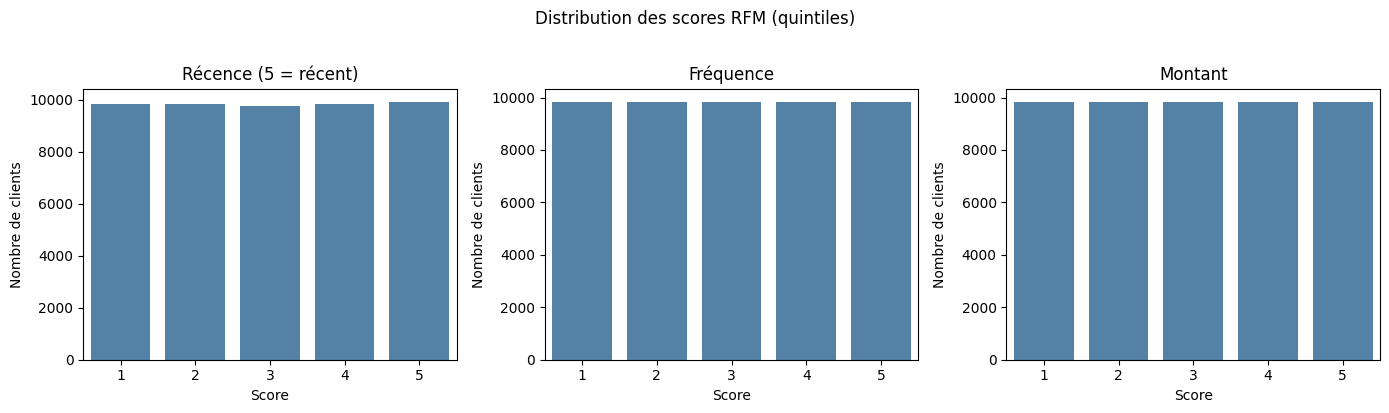

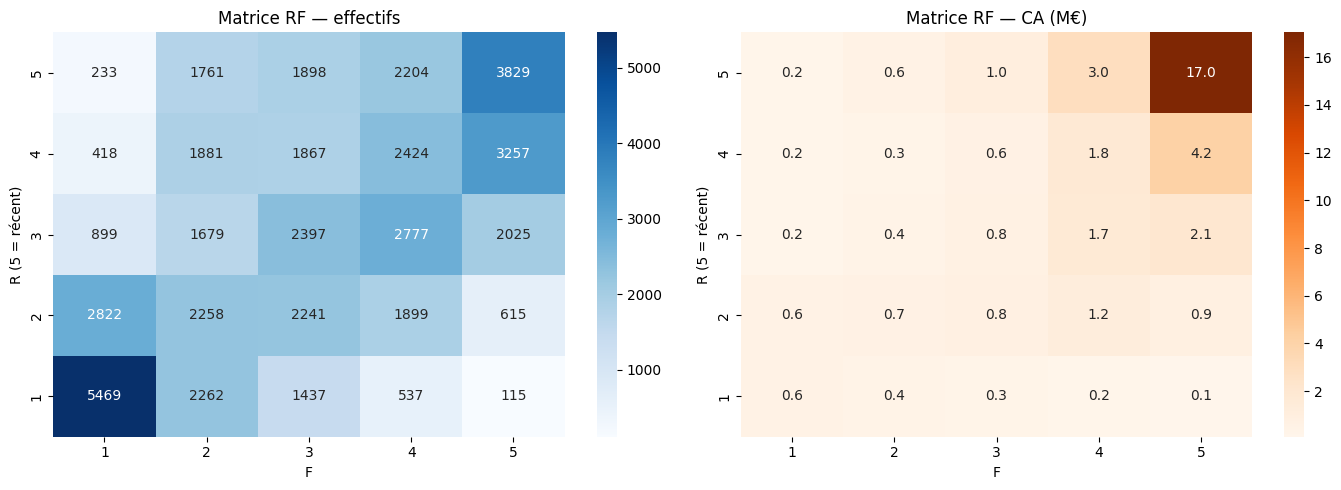

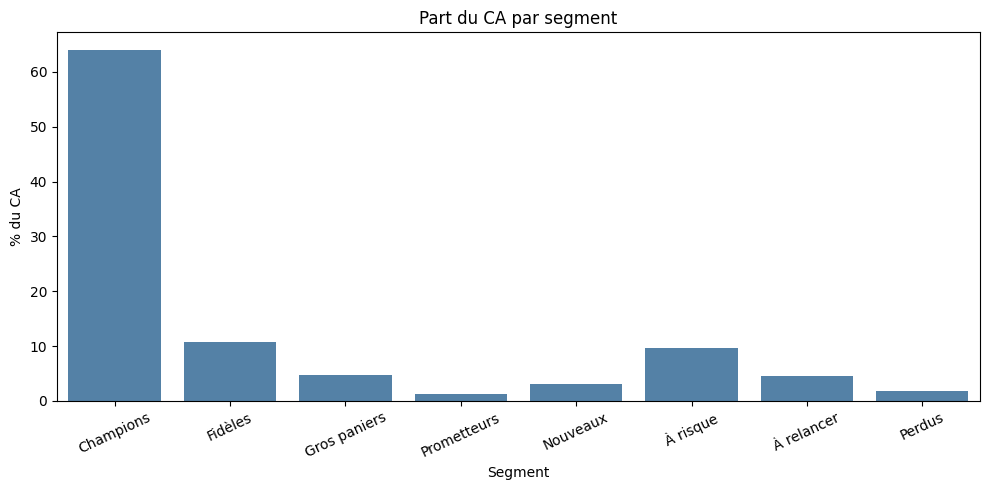

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes, ['R', 'F', 'M'], ['Récence (5 = récent)', 'Fréquence', 'Montant']):
    sns.countplot(data=rfm_df, x=col, color='steelblue', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Nombre de clients')
plt.suptitle('Distribution des scores RFM (quintiles)', y=1.02)
plt.tight_layout()
plt.show()

matrice_rf = (
    rfm_df.pivot_table(index='R', columns='F', values='customer_id', aggfunc='count', fill_value=0)
    .sort_index(ascending=False)
)
matrice_ca = (
    rfm_df.pivot_table(index='R', columns='F', values='monetary', aggfunc='sum', fill_value=0)
    .sort_index(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(matrice_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matrice RF — effectifs')
axes[0].set_xlabel('F')
axes[0].set_ylabel('R (5 = récent)')
sns.heatmap(matrice_ca / 1e6, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1])
axes[1].set_title('Matrice RF — CA (M€)')
axes[1].set_xlabel('F')
axes[1].set_ylabel('R (5 = récent)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=seg_table.reset_index(),
    x='segment', y='pct_ca', color='steelblue', ax=ax
)
ax.set_title('Part du CA par segment')
ax.set_xlabel('Segment')
ax.set_ylabel('% du CA')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


#### Lecture — scores et matrice RFM

Les barres R/F/M sont **plates par construction** (quintiles). L'information est dans le **croisement** : la matrice RF montre beaucoup de clients en bas à gauche (R faible, F faible) et le CA concentré en haut à droite (récents *et* fréquents).

C'est pour ça que « Champions proches » pèsent ~64 % du CA : ce n'est pas un hasard de naming, c'est la cellule haute valeur de la matrice.


#### Étape 3 : Visualisation et profilage

Profil pays / ancienneté par segment, puis scatter récence × montant. La relation n'est **pas linéaire** : un client très récent *et* un ancien gros compte peuvent tous deux valoir cher — d'où des actions différentes (accueillir vs reconquérir).


Profil démographique / ancienneté par segment :


,n,pct_france,n_pays,tenure_med,recency_med,monetary_med
segment,,,,,,
Champions,10108,91.5,24,504.0,53.0,819.0
Fidèles,6408,91.1,27,406.5,174.0,391.6
Gros paniers,1504,89.0,30,169.0,138.5,592.3
Prometteurs,3027,90.0,22,64.0,57.0,167.2
Nouveaux,4293,88.5,26,0.0,61.0,93.4
À risque,3754,93.2,33,268.0,446.0,550.9
À relancer,10131,91.7,36,137.0,368.0,183.7
Perdus,9979,91.9,34,0.0,657.0,67.6



Top pays (Champions) :


country
France            91.5
Germany            2.2
United Kingdom     2.1
Belgium            0.5
Spain              0.4
Portugal           0.4
Switzerland        0.4
Norway             0.3
Name: % clients, dtype: float64

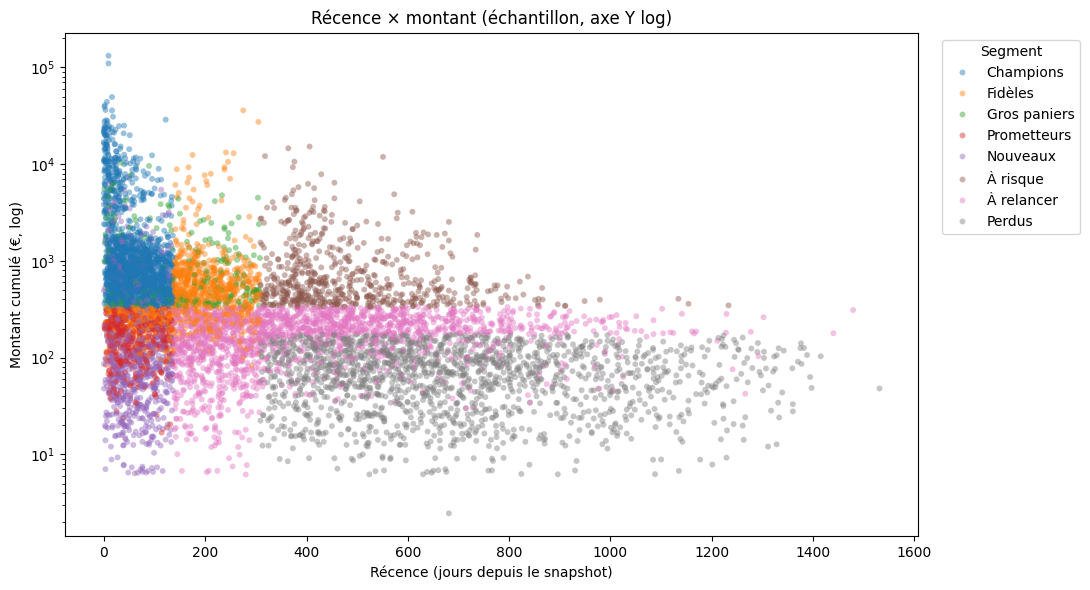

In [115]:
geo_seg = (
    rfm_df.assign(is_france=rfm_df['country'].eq('France'))
    .groupby('segment', observed=True)
    .agg(
        n=('customer_id', 'count'),
        pct_france=('is_france', 'mean'),
        n_pays=('country', 'nunique'),
        tenure_med=('tenure_days', 'median'),
        recency_med=('recency', 'median'),
        monetary_med=('monetary', 'median'),
    )
)
geo_seg['pct_france'] *= 100
print("Profil démographique / ancienneté par segment :")
display(geo_seg.loc[segment_order].round(1))

print("\nTop pays (Champions) :")
display(
    rfm_df[rfm_df['segment'] == 'Champions']['country']
    .value_counts(normalize=True)
    .head(8)
    .mul(100)
    .round(1)
    .rename('% clients')
)

sample = rfm_df.sample(n=min(8000, len(rfm_df)), random_state=42)
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=sample,
    x='recency',
    y='monetary',
    hue='segment',
    hue_order=segment_order,
    alpha=0.45,
    edgecolor='none',
    s=18,
)
plt.yscale('log')
plt.title('Récence × montant (échantillon, axe Y log)')
plt.xlabel('Récence (jours depuis le snapshot)')
plt.ylabel('Montant cumulé (€, log)')
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Lecture — profils et scatter

- **France ~91 %** dans presque tous les segments (un peu plus chez les À risque). La segmentation RFM **reproduit le biais géographique** du TP1 : ce n'est pas un axe de ciblage pays, c'est une limite à dire en présentation.
- **Ancienneté :** Champions / Fidèles ont une tenure médiane longue (plusieurs centaines de jours). Nouveaux et Perdus sont à 0 : les uns viennent d'arriver, les autres n'ont souvent jamais répété.
- **Scatter :** le nuage n'est pas une droite. Des points à récence faible *et* des points à récence élevée montent haut en montant (échelle log). Les Champions collent à gauche (récents, haut CA) ; les À risque sont à droite mais encore hauts ; les Perdus sont à droite et bas. D'où deux « fort potentiel » différents : récent à convertir vs ancien à sauver.


#### Étape 4 : Fiches segments et priorité

**Carte (8 segments)** — qui / potentiel / risque / action.

**1. Champions** (~21 % des clients, ~64 % du CA)  
- *Qui :* récents, fréquents, plus gros contributeurs. Longue ancienneté.  
- *Potentiel :* déjà réalisé ; le levier est la **rétention** et l'upsell coffret, pas l'acquisition.  
- *Risque :* faible churn immédiat, mais un départ coûte très cher.  
- *Action :* programme fidélité / accès early, e-mails relationnels, **pas** de discount agressif (on n'achète pas une vente qu'ils feraient déjà).  
- *Succès :* taux de rachat 90 jours ; NPS / désabonnement.

**2. Fidèles** (~13 % clients, ~11 % CA)  
- *Qui :* haute fréquence, récence encore saine, ticket plus bas que les Champions.  
- *Potentiel :* faire monter le panier (coffret, routine).  
- *Risque :* moyen si on les ignore.  
- *Action :* cross-sell Visage → Corps / coffret, contenu routine. Budget e-mail, pas media cher.  
- *Succès :* panier moyen à 90 jours.

**3. Gros paniers** (~3 % clients, ~5 % CA)  
- *Qui :* M élevé, pas encore assez fréquents pour Champions.  
- *Potentiel :* **fréquence** (les faire revenir).  
- *Risque :* un one-shot cher qui ne revient pas.  
- *Action :* relance 2ᵉ / 3ᵉ commande, abonnement / replenishment.  
- *Succès :* % avec une commande supplémentaire sous 60 jours.

**4. Prometteurs** (~6 % clients, ~1 % CA)  
- *Qui :* récents, fréquence moyenne, CA encore bas.  
- *Potentiel :* devenir Fidèles.  
- *Risque :* refroidissement après 1–2 visites.  
- *Action :* onboarding, éducation produit, petite offre de 2ᵉ achat.  
- *Succès :* passage à F≥4 dans 6 mois (suivi, pas un KPI D+30 magique).

**5. Nouveaux** (~9 % clients, ~3 % CA)  
- *Qui :* 1–2 factures, dernière récente. Tenure souvent 0.  
- *Potentiel :* tout le cycle de vie est devant.  
- *Risque :* one-shot définitif (déjà ~29 % de one-shot en base).  
- *Action :* welcome series, rappel D+14 / D+30, pas de pressions multi-canaux chères.  
- *Succès :* **taux de 2ᵉ commande à 30 jours**.

**6. À risque** (~8 % clients, ~10 % CA)  
- *Qui :* haut CA historique, inactifs (R 1–2).  
- *Potentiel :* récupérer une part du ~10 % de CA « endormi ».  
- *Risque :* **churn de haute valeur** — priorité n°1.  
- *Action :* win-back dédié (offre de retour, stock / nouveauté), appels éventuels sur les plus gros ; si pas de réponse, bascule Perdus.  
- *Succès :* **taux de réactivation 30 jours** (au moins 1 facture).

**7. À relancer** (~21 % clients, ~5 % CA)  
- *Qui :* milieu de matrice.  
- *Potentiel :* limité ; volume de contacts élevé.  
- *Risque :* gaspiller le budget en les traitant comme des VIP.  
- *Action :* newsletter / automatisations low-cost uniquement.  
- *Succès :* coût par e-mail vs commandes attribuées — arrêter si CPA absurde.

**8. Perdus** (~20 % clients si R,F,M ≤ 2 ; dont ~6 % en 111)  
- *Qui :* inactifs et faible historique.  
- *Potentiel :* quasi nul.  
- *Risque :* surtout le **sur-sollicitation** (spam, coût).  
- *Action :* **exclusion des campagnes coûteuses** ; 1 e-mail de clôture max, puis liste noire promo.  
- *Succès :* ne *pas* dépenser — KPI = budget non brûlé / plaintes évitées.


#### Priorité de traitement (1 = d'abord)

Si les n°1 et n°4 recevaient le même e-mail générique, la priorisation serait théorique. L'ordre ci-dessous **change l'intensité** (offre, canal, temps humain).

| Rang | Segment | Critère qui justifie le rang | Intensité réelle |
|---|---|---|---|
| 1 | À risque | **Risque de perte** d'un CA déjà prouvé (~10 %) | Win-back soigné, offre, suivi |
| 2 | Champions | **Valeur actuelle** (~64 % du CA) | Relationnel, pas de discount large |
| 3 | Gros paniers | **Potentiel de croissance** (fréquence) | Relance 2ᵉ commande |
| 4 | Nouveaux | Potentiel de cycle de vie, risque one-shot | Welcome auto, pas le même budget que 1 |
| 5 | Fidèles | Valeur stable à faire monter | E-mail routine / coffret |
| 6 | Prometteurs | Croissance plus incertaine | Nurture léger |
| 7 | À relancer | Faible CA / gros volume | Batch low-cost |
| 8 | Perdus | CA ~2 %, risque de spam | Exclusion media / catalogue |

**Cohérence budget :** ~80 % de l'effort humain et des offres ciblées sur les rangs 1–3 (À risque + Champions + Gros paniers). Les rangs 7–8 n'ont **pas** le même traitement que le 1.


In [116]:
# Métriques de succès « à suivre » (définies ici, à mesurer après campagne)
success_kpi = pd.DataFrame([
    {'segment': 'À risque', 'kpi': 'Taux de réactivation 30 jours', 'cible_indicative': '≥ 8 % des ciblés rachètent'},
    {'segment': 'Champions', 'kpi': 'Taux de rachat 90 jours', 'cible_indicative': 'Maintenir / ne pas baisser'},
    {'segment': 'Nouveaux', 'kpi': '2e commande sous 30 jours', 'cible_indicative': 'Battre le taux one-shot actuel'},
    {'segment': 'Gros paniers', 'kpi': 'Nouvelle facture sous 60 jours', 'cible_indicative': 'Monter la fréquence sans casser le panier'},
    {'segment': 'Perdus', 'kpi': 'Budget promo dépensé', 'cible_indicative': '≈ 0 € (exclusion)'},
])
print("Métriques de succès par segment prioritaire :")
display(success_kpi)


Métriques de succès par segment prioritaire :


,segment,kpi,cible_indicative
0,À risque,Taux de réactivation 30 jours,≥ 8 % des ciblés rachètent
1,Champions,Taux de rachat 90 jours,Maintenir / ne pas baisser
2,Nouveaux,2e commande sous 30 jours,Battre le taux one-shot actuel
3,Gros paniers,Nouvelle facture sous 60 jours,Monter la fréquence sans casser le panier
4,Perdus,Budget promo dépensé,≈ 0 € (exclusion)


#### Pour aller plus loin — quintiles sur 50 clients

Sur une base d'auto-entrepreneur (~50 clients), un quintile = **10 personnes** : le score « 5 » n'a plus de sens statistique (un seul gros devis bascule tout le classement).

**Paliers à la main (métier), exemples cosmétique DTC :**
- **R :** ≤ 30 j / 31–90 j / 91–180 j / > 180 j (cycle de rachat crème, pas un quintile).
- **F :** 1 commande / 2–3 / 4+ (on connaît ses habitués).
- **M :** seuils en euros du ticket typique (ex. < 50 € / 50–150 € / > 150 €), révisés une fois par an.

On nomme encore Champions / À risque / Perdus, mais avec **des dates et des euros**, pas `qcut`.


#### Pour aller plus loin — zero-party × un segment RFM

On croise **Champions** (et, en contrôle, le reste de la base) avec `declared_preference` : le RFM dit *combien / quand*, la zero-party dit *pourquoi / quel message*.


Taux de remplissage zero-party — Champions vs base RFM :


,Champions,Base RFM
declared_preference,37.6,37.8
age_bracket,41.8,42.4
life_stage,21.9,22.3
urban_density,19.5,19.7



Préférence déclarée parmi les répondants :


,Champions %,Base %,écart_pp
declared_preference,,,
Recherche vegan,14.7,14.3,0.3
Anti-imperfections,14.6,14.4,0.2
Peau sensible,14.5,14.6,-0.1
Sans parfum,14.4,14.0,0.4
Anti-âge,14.0,14.4,-0.4
Peau sèche,13.9,14.0,-0.1
Peau mixte,13.9,14.2,-0.3


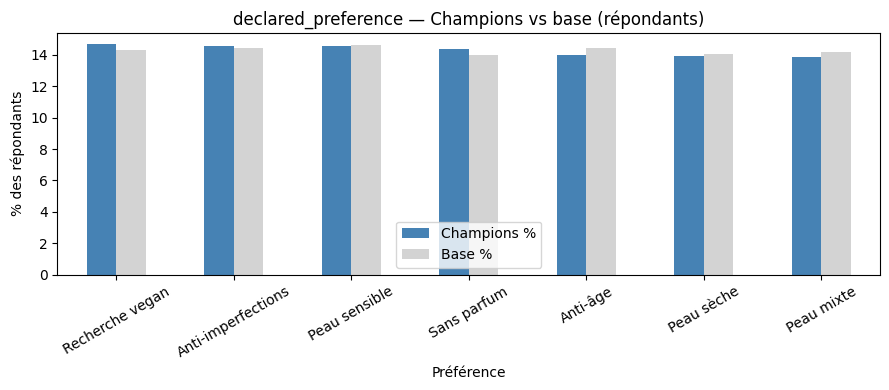

In [117]:
zp_cols = ['declared_preference', 'age_bracket', 'life_stage', 'urban_density']
rfm_zp = rfm_df.merge(
    customers_df_cleaned[['customer_id'] + zp_cols],
    on='customer_id',
    how='left',
)

champ = rfm_zp[rfm_zp['segment'] == 'Champions']
print("Taux de remplissage zero-party — Champions vs base RFM :")
fill = pd.DataFrame({
    'Champions': champ[zp_cols].notna().mean() * 100,
    'Base RFM': rfm_zp[zp_cols].notna().mean() * 100,
})
display(fill.round(1))

pref_champ = (
    champ['declared_preference']
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
    .rename('Champions %')
)
pref_all = (
    rfm_zp['declared_preference']
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
    .rename('Base %')
)
pref_cmp = pd.concat([pref_champ, pref_all], axis=1).fillna(0)
pref_cmp['écart_pp'] = pref_cmp['Champions %'] - pref_cmp['Base %']
print("\nPréférence déclarée parmi les répondants :")
display(pref_cmp.round(1))

fig, ax = plt.subplots(figsize=(9, 4))
pref_cmp[['Champions %', 'Base %']].plot(kind='bar', ax=ax, color=['steelblue', 'lightgray'])
ax.set_title('declared_preference — Champions vs base (répondants)')
ax.set_ylabel('% des répondants')
ax.set_xlabel('Préférence')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


#### Lecture du croisement Champions × `declared_preference`

- Le **taux de remplissage** des Champions est du même ordre que la base (~38 % de préférence, ~22 % de life_stage) : ce n'est pas un segment « plus déclaratif ».
- Parmi les **répondants**, le mix (peau sensible, vegan, sans parfum, anti-âge…) est **quasi plat** et très proche de la base. Le croisement **ne crée pas un persona démographique** plus net que le RFM seul.

**Est-ce que ça change le canal / le message ?**
- **Canal et offre RFM :** non — on continue un traitement Champions (fidélité, pas de braderie, relationnel).
- **Créative, pour le sous-ensemble qui a répondu :** oui. Un Champion « Recherche vegan » / « Sans parfum » doit recevoir la **même campagne de rétention**, mais un **objet et une landing** alignés (ingrédients, sans parfum), pas le visuel anti-âge générique.

Limite déjà vue au TP1 : ~22 % n'ont *aucun* champ zero-party. On s'en sert comme **personnalisation secondaire**, pas comme axe de clustering.


---

# Simulation : +1 % de budget pub (campagnes × segments × produits)

On part de `campaigns.csv` (`total_cost`, `revenue`, `conversion_rate`) et on descend au **segment RFM** et à la **catégorie produit** via `touchpoints.csv` (last-touch).

Dans le fichier, `conversion_rate` = conversions / clients atteints (pas / clics).

**Modèle (coût par client, taux de conversion et panier constants) :**
- +1 % de `total_cost` ⇒ +1 % de clients atteints
- conversions supplémentaires = 1 % × `n_clients` × `conversion_rate`
- CA supplémentaire = conversions supplémentaires × (`revenue` / `n_conversions`)

À l'échelle d'une campagne, ça revient à **+1 % du `revenue` actuel**. Pour **savoir où augmenter**, on compare le **ROAS** (`revenue` / `total_cost`) : un euro de plus là où le ROAS est le plus fort rapporte plus de CA.


In [ ]:
campaigns_df = pd.read_csv(DATA_DIR / "campaigns.csv")
campaigns_df.columns = campaigns_df.columns.str.strip()
campaigns_df["campaign_name"] = campaigns_df["campaign_name"].str.strip()

campaigns_df["delta_cost_1pct"] = campaigns_df["total_cost"] * 0.01
campaigns_df["extra_conversions"] = campaigns_df["n_clients"] * 0.01 * campaigns_df["conversion_rate"]
campaigns_df["aov"] = campaigns_df["revenue"] / campaigns_df["n_conversions"]
campaigns_df["delta_ca_1pct"] = campaigns_df["extra_conversions"] * campaigns_df["aov"]
campaigns_df["ca_par_euro"] = campaigns_df["revenue"] / campaigns_df["total_cost"]

print("Campagnes — effet d'un +1 % de budget (conversion_rate et panier constants) :")
display(
    campaigns_df[[
        "campaign_name", "primary_channel", "total_cost", "revenue",
        "conversion_rate", "roas", "delta_cost_1pct", "extra_conversions", "delta_ca_1pct",
    ]]
    .sort_values("roas", ascending=False)
    .round(2)
)

budget_total = campaigns_df["total_cost"].sum()
ca_total_camp = campaigns_df["revenue"].sum()
print(f"\nBudget total : {budget_total:,.0f} € | CA attribué : {ca_total_camp:,.0f} € | ROAS global : {ca_total_camp / budget_total:.2f}")
print("Si on place +1 % du budget GLOBAL sur UNE seule campagne (meilleur arbitrage) :")
realloc = campaigns_df.copy()
realloc["delta_ca_si_1pct_global"] = 0.01 * budget_total * realloc["ca_par_euro"]
display(
    realloc[["campaign_name", "roas", "delta_ca_1pct", "delta_ca_si_1pct_global"]]
    .sort_values("delta_ca_si_1pct_global", ascending=False)
    .round(2)
)


In [ ]:
touchpoints_df = pd.read_csv(DATA_DIR / "touchpoints.csv")
touchpoints_df["invoice_id"] = pd.to_numeric(touchpoints_df["invoice_id"], errors="coerce")

# Recette de conversion : revenue campagne répartie à parts égales entre conversions last-touch
rev_par_conv = campaigns_df.set_index("campaign_name")["revenue"] / campaigns_df.set_index("campaign_name")["n_conversions"]

conv_df = touchpoints_df.loc[touchpoints_df["converted"] == 1, ["customer_id", "invoice_id", "campaign_name"]].copy()
conv_df["revenue_attrib"] = conv_df["campaign_name"].map(rev_par_conv)

clicks_df = touchpoints_df.loc[touchpoints_df["click"] == 1, ["customer_id", "campaign_name"]].copy()
cost_df = touchpoints_df[["customer_id", "campaign_name", "cost"]].copy()

# Segments RFM (clients hors table → Hors RFM)
rfm_seg = rfm_df[["customer_id", "segment"]].copy()
rfm_seg["segment"] = rfm_seg["segment"].astype(str)

def with_segment(df):
    out = df.merge(rfm_seg, on="customer_id", how="left")
    out["segment"] = out["segment"].fillna("Hors RFM")
    return out

cost_s = with_segment(cost_df).groupby("segment", as_index=False)["cost"].sum()
clicks_s = with_segment(clicks_df).groupby("segment", as_index=False).size().rename(columns={"size": "n_clicks"})
conv_s = with_segment(conv_df).groupby("segment", as_index=False).agg(
    n_conversions=("customer_id", "count"),
    revenue=("revenue_attrib", "sum"),
)

seg_camp = (
    cost_s.merge(clicks_s, on="segment", how="outer")
    .merge(conv_s, on="segment", how="outer")
    .fillna(0)
)
seg_camp["conversion_rate"] = np.where(seg_camp["n_clicks"] > 0, seg_camp["n_conversions"] / seg_camp["n_clicks"], np.nan)
seg_camp["roas"] = np.where(seg_camp["cost"] > 0, seg_camp["revenue"] / seg_camp["cost"], np.nan)
seg_camp["aov"] = np.where(seg_camp["n_conversions"] > 0, seg_camp["revenue"] / seg_camp["n_conversions"], np.nan)
seg_camp["delta_cost_1pct"] = seg_camp["cost"] * 0.01
seg_camp["extra_conversions"] = seg_camp["n_clicks"] * 0.01 * seg_camp["conversion_rate"]
seg_camp["delta_ca_1pct"] = seg_camp["extra_conversions"] * seg_camp["aov"]
seg_camp["delta_ca_si_1pct_global"] = 0.01 * budget_total * seg_camp["roas"]

order = [s for s in segment_order if s in set(seg_camp["segment"])] + ["Hors RFM"]
seg_camp["segment"] = pd.Categorical(seg_camp["segment"], categories=order, ordered=True)
seg_camp = seg_camp.sort_values("segment")

print("Segments RFM — +1 % sur CE segment vs +1 % du budget global placé ICI :")
display(
    seg_camp[[
        "segment", "cost", "revenue", "conversion_rate", "roas",
        "delta_ca_1pct", "delta_ca_si_1pct_global",
    ]].round(2)
)


In [ ]:
# Produits = category des factures converties (last-touch)
tx_cat = transactions_df_cleaned[["invoice_id", "category", "line_total"]].copy()
tx_cat["invoice_id"] = pd.to_numeric(tx_cat["invoice_id"], errors="coerce")
tx_cat = tx_cat.dropna(subset=["invoice_id", "category"])
tx_cat["share"] = tx_cat["line_total"] / tx_cat.groupby("invoice_id")["line_total"].transform("sum")
tx_cat["share"] = tx_cat["share"].fillna(0)

conv_prod = conv_df.merge(tx_cat[["invoice_id", "category", "share"]], on="invoice_id", how="left")
conv_prod["category"] = conv_prod["category"].fillna("Inconnu")
conv_prod["revenue"] = conv_prod["revenue_attrib"] * conv_prod["share"].fillna(1)

# Coût / clics : pas de produit sur le touchpoint → on ventile le coût du client au prorata de son CA converti par catégorie
rev_client_cat = conv_prod.groupby(["customer_id", "category"], as_index=False)["revenue"].sum()
rev_client_cat["share_client"] = rev_client_cat["revenue"] / rev_client_cat.groupby("customer_id")["revenue"].transform("sum")

cost_p = with_segment(cost_df).merge(rev_client_cat[["customer_id", "category", "share_client"]], on="customer_id", how="left")
cost_p["category"] = cost_p["category"].fillna("Sans conversion")
cost_p["share_client"] = cost_p["share_client"].fillna(1)
cost_p["cost"] = cost_p["cost"] * cost_p["share_client"]
cost_p = cost_p.groupby("category", as_index=False)["cost"].sum()

clicks_p = with_segment(clicks_df).merge(rev_client_cat[["customer_id", "category", "share_client"]], on="customer_id", how="left")
clicks_p["category"] = clicks_p["category"].fillna("Sans conversion")
clicks_p["share_client"] = clicks_p["share_client"].fillna(1)
clicks_p["n_clicks"] = clicks_p["share_client"]
clicks_p = clicks_p.groupby("category", as_index=False)["n_clicks"].sum()

prod_camp = (
    cost_p.merge(clicks_p, on="category", how="outer")
    .merge(
        conv_prod.groupby("category", as_index=False).agg(
            n_conversions=("share", "sum"),
            revenue=("revenue", "sum"),
        ),
        on="category",
        how="outer",
    )
    .fillna(0)
)
prod_camp["conversion_rate"] = np.where(prod_camp["n_clicks"] > 0, prod_camp["n_conversions"] / prod_camp["n_clicks"], np.nan)
prod_camp["roas"] = np.where(prod_camp["cost"] > 0, prod_camp["revenue"] / prod_camp["cost"], np.nan)
prod_camp["aov"] = np.where(prod_camp["n_conversions"] > 0, prod_camp["revenue"] / prod_camp["n_conversions"], np.nan)
prod_camp["delta_ca_1pct"] = prod_camp["n_clicks"] * 0.01 * prod_camp["conversion_rate"] * prod_camp["aov"]
prod_camp["delta_ca_si_1pct_global"] = 0.01 * budget_total * prod_camp["roas"]
prod_camp = prod_camp.sort_values("roas", ascending=False)

print("Catégories produit — +1 % de pub :")
display(
    prod_camp[[
        "category", "cost", "revenue", "conversion_rate", "roas",
        "delta_ca_1pct", "delta_ca_si_1pct_global",
    ]].round(2)
)


In [ ]:
# Croisement segment × catégorie : où mettre le +1 % global
conv_sp = with_segment(conv_prod)
cross = (
    conv_sp.groupby(["segment", "category"], as_index=False)
    .agg(n_conversions=("share", "sum"), revenue=("revenue", "sum"))
)

cost_sp = with_segment(cost_df).merge(rev_client_cat[["customer_id", "category", "share_client"]], on="customer_id", how="left")
cost_sp["category"] = cost_sp["category"].fillna("Sans conversion")
cost_sp["share_client"] = cost_sp["share_client"].fillna(1)
cost_sp["cost"] = cost_sp["cost"] * cost_sp["share_client"]
cost_sp = cost_sp.groupby(["segment", "category"], as_index=False)["cost"].sum()

cross = cost_sp.merge(cross, on=["segment", "category"], how="left").fillna({"n_conversions": 0, "revenue": 0})
cross = cross[cross["category"].ne("Sans conversion") & cross["cost"].gt(0)]
cross["roas"] = cross["revenue"] / cross["cost"]
cross["delta_ca_si_1pct_global"] = 0.01 * budget_total * cross["roas"]
cross = cross.sort_values("delta_ca_si_1pct_global", ascending=False)

print("Top 15 combinaisons segment × produit si on place +1 % du budget pub GLOBAL ici :")
display(cross.head(15).round(2))

heat = (
    cross.pivot_table(index="segment", columns="category", values="roas", aggfunc="mean")
    .reindex(index=[s for s in order if s != "Hors RFM"])
)
plt.figure(figsize=(10, 5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("ROAS par segment RFM × catégorie produit")
plt.xlabel("Catégorie")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=seg_camp.dropna(subset=["roas"]), x="segment", y="delta_ca_si_1pct_global", color="steelblue", ax=axes[0])
axes[0].set_title("CA en plus si +1 % du budget global va au segment")
axes[0].set_ylabel("Δ CA (€)")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(data=prod_camp[prod_camp["category"] != "Sans conversion"], x="category", y="delta_ca_si_1pct_global", color="steelblue", ax=axes[1])
axes[1].set_title("CA en plus si +1 % du budget global va à la catégorie")
axes[1].set_ylabel("Δ CA (€)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


#### Lecture — où augmenter les campagnes de pub

Le **+1 % « sur place »** (scaler chaque campagne / segment de 1 %) donne un Δ CA égal à 1 % du CA déjà attribué : ça favorise les gros volumes, pas forcément les plus efficaces.

L'arbitrage utile est **+1 % du budget total déplacé vers la meilleure poche** (colonne `delta_ca_si_1pct_global` \(= 1\% \times budget\_global \times ROAS\)).

**Campagnes :** augmenter en priorité celles au **ROAS le plus haut** (`Winter_Promo` ~5,4, puis `Black_Friday` / `Back_to_School` ~4,6). **Ne pas** augmenter `Summer_Sale` (~2,7) : un euro de plus y rapporte presque 2× moins.

**Segments :** mettre le budget incrémental là où le ROAS pub est le plus fort (souvent **Champions / Fidèles / Gros paniers** : déjà convertisseurs). Les **Perdus** : conversion et ROAS faibles → pas de hausse de media cher.

**Produits :** pousser les catégories au meilleur ROAS (souvent **Coffret** et **Visage** : panier / conversion plus élevés). **Frais** et les poches sans conversion : hors cible pub.

**Limite :** le modèle est **linéaire** (pas de saturation, pas d'incrémentalité vraie). C'est un **classement pour prioriser un test**, pas une prévision de CA garanti. Le Jour 4 (A/B) devra valider la hausse sur le couple gagnant.
